# Mistake Identification in Pedagogical Conversations

## Mistake Identification in Pedagogical Conversations

### Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

### Dataset Structure
- **trainset.json**: 300 conversations with labels (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

### Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-base for excellent reasoning capabilities
2. **Training Strategy**: Train on trainset with validation split
3. **Evaluation**: Make predictions on dev and test sets
4. **Output**: Save predictions as CSV files for each model's responses

## 1. Import the dataset

In [1]:
import json

# Read all JSON files
json_files = [
    '../../data/trainset.json',
    '../../data/testset_with_answers.json',
    '../../data/dev_testset_with_answers.json'
]

all_conversation_ids = set()

for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for item in data:
                if 'conversation_id' in item:
                    all_conversation_ids.add(item['conversation_id'])
        print(f"Loaded {file_path}: {len([item for item in data if 'conversation_id' in item])} conversations")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nTotal unique conversation IDs across all files: {len(all_conversation_ids)}")

File not found: ../../data/trainset.json
File not found: ../../data/testset_with_answers.json
File not found: ../../data/dev_testset_with_answers.json

Total unique conversation IDs across all files: 0


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Explore Data

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import os


def extract_student_responses_from_conversation(conv_history: str) -> str:
    """
    Extract and combine all student responses from a conversation history.
    Expected format: lines starting with 'Student:'.

    Args:
        conv_history (str): Full conversation text.

    Returns:
        str: Combined student responses.
    """
    student_responses = []
    for line in conv_history.split('\n'):
        line = line.strip()
        if line.startswith('Student:'):
            response = line.replace('Student:', '').strip()
            if response:
                student_responses.append(response)
    return ' '.join(student_responses).strip()


def load_dataset(file_path: str, is_train: bool = True) -> pd.DataFrame:
    """
    Load dataset (train or test) from JSON file.

    Args:
        file_path (str): Path to the dataset file.
        is_train (bool): Whether the dataset contains annotations.

    Returns:
        pd.DataFrame: Structured dataframe ready for ML models.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    samples = []
    for conversation in data:
        conv_history = conversation.get('conversation_history', '')
        conv_id = conversation.get('conversation_id', '')
        student_conv = extract_student_responses_from_conversation(conv_history)

        tutor_responses = conversation.get('tutor_responses', {})
        for model_name, response_data in tutor_responses.items():
            sample = {
                'conversation_id': conv_id,
                'student_responses': student_conv,
                'tutor_response': response_data.get('response', ''),
                'model': model_name,
                'answer_key': response_data.get('answer_key', ''),
                'conversation_history': conv_history
            }

            # Include labels only if present (training set)
            if is_train and 'annotation' in response_data:
                ann = response_data['annotation']
                if 'Mistake_Identification' in ann:
                    sample['label'] = ann['Mistake_Identification']

            samples.append(sample)

    df = pd.DataFrame(samples)
    return df


def visualize_label_distribution(df: pd.DataFrame, output_path: str = 'label_distribution.png'):
    """
    Visualize and save the label distribution for training data.
    """
    if 'label' not in df.columns:
        print("⚠️ No 'label' column found — skipping visualization.")
        return

    counts = df['label'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(counts.index, counts.values,
                  color=['#2ecc71', '#f39c12', '#e74c3c'],
                  edgecolor='black', linewidth=1.5)

    ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, count + 5,
                f'{count}\n({count / len(df) * 100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"📊 Saved label distribution plot to: {output_path}")


# ==========================
# MAIN EXECUTION
# ==========================
if __name__ == "__main__":
    print("📥 Loading datasets...")
    base_path = "../../../data"

    train_path = os.path.join(base_path, "trainset_with_answers.json")
    dev_path = os.path.join(base_path, "dev_testset_with_answers.json")
    test_path = os.path.join(base_path, "testset_with_answers.json")

    train_df = load_dataset(train_path, is_train=True)
    dev_df = load_dataset(dev_path, is_train=False)
    test_df = load_dataset(test_path, is_train=False)

    print("\n" + "=" * 60)
    print("✅ Dataset Statistics")
    print("=" * 60)
    print(f"Training samples (with labels): {len(train_df)}")
    print(f"Dev samples (for inference): {len(dev_df)}")
    print(f"Test samples (for inference): {len(test_df)}")

    if 'label' in train_df.columns:
        print("\n" + "=" * 60)
        print("📈 Training Set Label Distribution")
        print("=" * 60)
        print(train_df['label'].value_counts())
        visualize_label_distribution(train_df)
    else:
        print("⚠️ No labels found in training data. Skipping visualization.")


📥 Loading datasets...

✅ Dataset Statistics
Training samples (with labels): 2476
Dev samples (for inference): 1214
Test samples (for inference): 1214

📈 Training Set Label Distribution
label
Yes               1932
No                 370
To some extent     174
Name: count, dtype: int64
📊 Saved label distribution plot to: label_distribution.png
📊 Saved label distribution plot to: label_distribution.png


## 3. Data Analysis & Insights

In [4]:
# # Analyze text lengths
# train_df['history_length'] = train_df['conversation_history'].str.len()
# train_df['response_length'] = train_df['tutor_response'].str.len()
# train_df['total_length'] = train_df['history_length'] + train_df['response_length']

# print("Text Length Statistics:")
# print(f"{'='*60}")
# print(f"Conversation History - Mean: {train_df['history_length'].mean():.0f}, Max: {train_df['history_length'].max()}")
# print(f"Tutor Response - Mean: {train_df['response_length'].mean():.0f}, Max: {train_df['response_length'].max()}")
# print(f"Total Length - Mean: {train_df['total_length'].mean():.0f}, Max: {train_df['total_length'].max()}")

# # Check for samples with very long text (might need truncation)
# print(f"\nSamples with total length > 2000 chars: {(train_df['total_length'] > 2000).sum()}")
# print(f"Samples with total length > 3000 chars: {(train_df['total_length'] > 3000).sum()}")

# # Example samples
# print(f"\n{'='*60}")
# print("Example Sample:")
# print(f"{'='*60}")
# sample = train_df.iloc[0]
# print(f"Label: {sample['label']}")
# print(f"\nConversation History:\n{sample['conversation_history'][:300]}...")
# print(f"\nTutor Response:\n{sample['tutor_response']}")
# print(f"{'='*60}")

## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [5]:
# Model selection - DeBERTa-v3-large is excellent for understanding nuanced text
MODEL_NAME = "microsoft/deberta-v3-base"
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")

Selected Model: microsoft/deberta-v3-base
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656


## 5. Create PyTorch Dataset

In [6]:
from sklearn.model_selection import train_test_split

class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response
        # text = f"Model: {row['model']} [SEP] Tutor Response: {row['tutor_response']} [SEP] Student Responses: {row['student_responses']}"
        text = f"Model: {row['model']} [SEP] Tutor Response: {row['tutor_response']} [SEP] {row['student_responses']} [SEP] Answer: {row['answer_key']}"

        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512


# Step 1: Split 70% train, 30% temp (val + test)
train_data, temp_data = train_test_split(
    train_df, test_size=0.3, random_state=42, stratify=train_df['label']
)

# Step 2: Split temp_data into 50/50 for val and test → 15% each of total
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_data['label']
)

print(f"Data split:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples (from trainset)")
print(f"  Test: {len(test_data)} samples (from trainset)")
print(f"  Dev (inference): {len(dev_df)} samples (no labels)")
print(f"  Test (inference): {len(test_df)} samples (no labels)")


# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
testing_dataset = MistakeIdentificationDataset(test_data, tokenizer, MAX_LENGTH, has_labels=True)

dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False)
test_dataset = MistakeIdentificationDataset(test_df, tokenizer, MAX_LENGTH, has_labels=False)

print(f"\nDatasets created successfully!")

# Test the dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels']} ({id2label[sample['labels'].item()]})")

sample_inf = dev_dataset[0]
print(f"\nSample from inference dataset (dev):")
print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
print(f"  Has label: {'labels' in sample_inf}")

Data split:
  Training: 1733 samples
  Validation: 371 samples (from trainset)
  Test: 372 samples (from trainset)
  Dev (inference): 1214 samples (no labels)
  Test (inference): 1214 samples (no labels)

Datasets created successfully!

Sample from training dataset:
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Label: 0 (Yes)

Sample from inference dataset (dev):
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Has label: False


## 6. Handle Data Imbalance (Multiple Strategies)

We'll use a **comprehensive approach** to handle class imbalance:
1. **Class Weights** - Give more importance to minority classes in loss
2. **Stratified Sampling** - Ensure balanced validation split
3. **Data Augmentation** (optional) - Oversample minority classes
4. **Focal Loss** (optional) - Focus on hard-to-classify examples

In [7]:
# ============================================================================
# STRATEGY 1: Calculate Class Weights (Inverse Frequency)
# ============================================================================
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print("\nOriginal Class Distribution:")
for label, count in train_df['label'].value_counts().sort_index().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

# ============================================================================
# STRATEGY 2: Oversample Minority Classes (SMOTE-like approach)
# ============================================================================
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label', strategy='oversample'):
    """
    Balance dataset by oversampling minority classes.
    """
    if strategy == 'none':
        return df
    
    # Get class counts
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        
        if strategy == 'oversample':
            # Oversample to match majority class
            if len(class_df) < max_count:
                class_df_resampled = resample(
                    class_df,
                    n_samples=max_count,
                    replace=True,
                    random_state=42
                )
                balanced_dfs.append(class_df_resampled)
            else:
                balanced_dfs.append(class_df)
        elif strategy == 'undersample':
            # Undersample to match minority class
            min_count = class_counts.min()
            class_df_resampled = resample(
                class_df,
                n_samples=min_count,
                replace=False,
                random_state=42
            )
            balanced_dfs.append(class_df_resampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Choose strategy: 'none', 'oversample', or 'undersample'
# Recommendation: Use 'none' with class weights, or 'oversample' for more data
BALANCE_STRATEGY = 'none'  # Change to 'oversample' if you want more balanced data

if BALANCE_STRATEGY != 'none':
    print(f"\n{'='*80}")
    print(f"APPLYING {BALANCE_STRATEGY.upper()} STRATEGY")
    print(f"{'='*80}")
    
    train_df_balanced = balance_dataset(train_df, strategy=BALANCE_STRATEGY)
    
    print(f"\nBalanced Class Distribution:")
    for label, count in train_df_balanced['label'].value_counts().sort_index().items():
        percentage = (count / len(train_df_balanced)) * 100
        print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%)")
    
    # Update training dataframe
    train_df = train_df_balanced
    print(f"\n✓ Training data balanced: {len(train_df)} total samples")
else:
    print(f"\n{'='*80}")
    print("Using WEIGHTED LOSS without data resampling")
    print(f"{'='*80}")

# ============================================================================
# STRATEGY 3: Compute Effective Number of Samples (for better weights)
# ============================================================================
def compute_effective_weights(labels, beta=0.9999):
    """
    Compute class weights using Effective Number of Samples.
    Paper: "Class-Balanced Loss Based on Effective Number of Samples"
    
    This gives better weights than inverse frequency for highly imbalanced data.
    """
    class_counts = Counter(labels)
    total_samples = len(labels)
    
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    
    # Normalize weights
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    
    return effective_weights

# Calculate effective weights (alternative to balanced weights)
effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
effective_weights_tensor = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"\n{'='*80}")
print("WEIGHT COMPARISON")
print(f"{'='*80}")
print("\nBalanced Weights (sklearn):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {class_weights[i]:.4f}")

print("\nEffective Number Weights (beta=0.9999):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {effective_weights_array[i]:.4f}")

# ============================================================================
# FINAL SELECTION: Choose which weights to use
# ============================================================================
# Options: class_weights_tensor (balanced) or effective_weights_tensor (EN-based)
USE_EFFECTIVE_WEIGHTS = False  # Set to True to use Effective Number weights

if USE_EFFECTIVE_WEIGHTS:
    final_weights = effective_weights_tensor
    print(f"\n✓ Using Effective Number weights")
else:
    final_weights = class_weights_tensor
    print(f"\n✓ Using Balanced (sklearn) weights")

# Store for trainer
class_weights_tensor = final_weights

print(f"\n{'='*80}")
print("Class imbalance handling configured successfully!")
print(f"{'='*80}")

CLASS IMBALANCE ANALYSIS

Original Class Distribution:
  No                  :  370 samples ( 14.9%) → weight: 2.231
  To some extent      :  174 samples (  7.0%) → weight: 4.743
  Yes                 : 1932 samples ( 78.0%) → weight: 0.427

Using WEIGHTED LOSS without data resampling

WEIGHT COMPARISON

Balanced Weights (sklearn):
  Yes                 : 0.4272
  To some extent      : 4.7433
  No                  : 2.2306

Effective Number Weights (beta=0.9999):
  Yes                 : 0.1873
  To some extent      : 1.9071
  No                  : 0.9056

✓ Using Balanced (sklearn) weights

Class imbalance handling configured successfully!


## 7. Define Custom Trainer with Weighted Loss

In [8]:
class WeightedTrainer(Trainer):
    """
    Custom Trainer with support for:
    1. Weighted Cross-Entropy Loss
    2. Focal Loss (optional)
    """
    
    def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha  # Can be None or tensor of per-class weights
        self.focal_gamma = focal_gamma
        
        # Move class weights to the correct device
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)
        
        # Move focal alpha to the correct device
        if self.focal_alpha is not None:
            self.focal_alpha = self.focal_alpha.to(self.args.device)
        
        if self.use_focal_loss:
            print(f"Using Focal Loss with gamma={focal_gamma}")
            if focal_alpha is not None:
                print(f"  Alpha (class weights): {focal_alpha}")
        else:
            print(f"Using Weighted Cross-Entropy Loss")
            if class_weights is not None:
                print(f"  Class weights: {class_weights}")
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute custom loss (weighted CE or focal loss).
        """
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        if self.use_focal_loss:
            # Focal Loss implementation
            # Ensure focal_alpha is on the correct device
            alpha_weight = self.focal_alpha if self.focal_alpha is None else self.focal_alpha.to(logits.device)
            
            ce_loss = F.cross_entropy(
                logits, 
                labels, 
                weight=alpha_weight,
                reduction='none'
            )
            pt = torch.exp(-ce_loss)  # pt is the probability of correct class
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss
        else:
            # Weighted Cross-Entropy Loss
            # Ensure class_weights is on the correct device
            weights = self.class_weights if self.class_weights is None else self.class_weights.to(logits.device)
            
            loss = F.cross_entropy(
                logits,
                labels,
                weight=weights
            )
        
        return (loss, outputs) if return_outputs else loss

## 8. Define Metrics

In [9]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

In [10]:
# ============================================================================
# CONFIGURE TRAINING STRATEGY
# ============================================================================

# Loss Configuration
USE_FOCAL_LOSS = True  # Set to True to use Focal Loss instead of Weighted CE
FOCAL_GAMMA = 2.0       # Focal loss gamma parameter (higher = more focus on hard examples)

print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

if USE_FOCAL_LOSS:
    print(f"\n✓ Using Focal Loss")
    print(f"  - Gamma: {FOCAL_GAMMA}")
    print(f"  - Alpha (class weights): {class_weights_tensor.cpu().numpy()}")
    focal_alpha = class_weights_tensor
else:
    print(f"\n✓ Using Weighted Cross-Entropy Loss")
    print(f"  - Class weights: {class_weights_tensor.cpu().numpy()}")
    focal_alpha = None

# Training Arguments - Using Optimized Hyperparameters from Trial 35
training_args = TrainingArguments(
    output_dir='./results/mistake-identification-deberta',
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.05271923549836644,
    weight_decay=0.1815239768683226,
    learning_rate=6.584378322193506e-06,
    lr_scheduler_type="cosine_with_restarts",
    gradient_accumulation_steps=1,
    max_grad_norm=0.5395517332946363,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    save_total_limit=2,
)

print(f"\nTraining Parameters (Trial 35 - F1 Macro: 0.6275):")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Warmup ratio: {training_args.warmup_ratio}")
print(f"  - Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  - LR scheduler: {training_args.lr_scheduler_type}")
print(f"  - Gradient accumulation: {training_args.gradient_accumulation_steps}")



print("="*80)
print(f"  - Mixed precision (FP16): {training_args.fp16}")
print(f"  - Max grad norm: {training_args.max_grad_norm}")
print(f"  - Weight decay: {training_args.weight_decay}")
print(f"  - Mixed precision (FP16): {training_args.fp16}")
print("="*80)

TRAINING CONFIGURATION

✓ Using Focal Loss
  - Gamma: 2.0
  - Alpha (class weights): [0.42719117 4.743295   2.2306306 ]

Training Parameters (Trial 35 - F1 Macro: 0.6275):
  - Epochs: 20
  - Warmup ratio: 0.05271923549836644
  - Batch size (eval): 32
  - LR scheduler: SchedulerType.COSINE_WITH_RESTARTS
  - Gradient accumulation: 1
  - Mixed precision (FP16): True
  - Max grad norm: 0.5395517332946363
  - Weight decay: 0.1815239768683226
  - Mixed precision (FP16): True

Training Parameters (Trial 35 - F1 Macro: 0.6275):
  - Epochs: 20
  - Warmup ratio: 0.05271923549836644
  - Batch size (eval): 32
  - LR scheduler: SchedulerType.COSINE_WITH_RESTARTS
  - Gradient accumulation: 1
  - Mixed precision (FP16): True
  - Max grad norm: 0.5395517332946363
  - Weight decay: 0.1815239768683226
  - Mixed precision (FP16): True


In [11]:
# Load the pre-trained model for sequence classification
print("="*80)
print("LOADING MODEL")
print("="*80)

# Apply optimized dropout rates from Trial 35
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=0.19805387187992401,
    attention_probs_dropout_prob=0.2596999242694033
)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nModel: {MODEL_NAME}")
print(f"Number of labels: 3")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\n✓ Model loaded successfully!")
print("="*80)

LOADING MODEL


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model: microsoft/deberta-v3-base
Number of labels: 3
Device: cuda
Model parameters: 184,424,451
Trainable parameters: 184,424,451

✓ Model loaded successfully!


## 10. Initialize Trainer and Start Training

In [12]:
# Initialize the custom trainer with focal loss support
trainer = WeightedTrainer(
    class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
    focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Use validation split from trainset
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=7)]
)

print("="*80)
print("TRAINER INITIALIZED")
print("="*80)
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)} (from trainset)")

if USE_FOCAL_LOSS:
    print(f"  - Loss function: Focal Loss (gamma={FOCAL_GAMMA})")
else:
    print(f"  - Loss function: Weighted Cross-Entropy")

print(f"  - Early stopping: patience=5")
print(f"  - Best model selection: F1-macro")

print(f"\n{'='*80}")
print("STARTING TRAINING")
print(f"{'='*80}\n")

# Train the model
train_result = trainer.train()

print(f"\n{'='*80}")
print("TRAINING COMPLETED")
print(f"{'='*80}")
print(f"Final training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"{'='*80}")

Using Focal Loss with gamma=2.0
  Alpha (class weights): tensor([0.4272, 4.7433, 2.2306])
TRAINER INITIALIZED
  - Training samples: 1733
  - Validation samples: 371 (from trainset)
  - Loss function: Focal Loss (gamma=2.0)
  - Early stopping: patience=5
  - Best model selection: F1-macro

STARTING TRAINING



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,No log,0.687019,0.234501,0.208618,0.291010,0.328841,0.128788,0.168224,0.753086,0.071429,0.173077,0.210345,0.653846,0.163636
2,0.713700,nan,0.218329,0.187551,0.264154,0.303030,0.143345,0.116279,0.753425,0.078652,0.161290,0.189655,0.807692,0.090909
3,0.000000,nan,0.264151,0.209805,0.326249,0.384615,0.136691,0.108108,0.750000,0.075397,0.210526,0.258621,0.730769,0.072727
4,0.000000,nan,0.218329,0.187551,0.264154,0.303030,0.143345,0.116279,0.753425,0.078652,0.161290,0.189655,0.807692,0.090909
5,0.000000,nan,0.264151,0.209805,0.326249,0.384615,0.136691,0.108108,0.750000,0.075397,0.210526,0.258621,0.730769,0.072727
6,0.000000,nan,0.218329,0.187551,0.264154,0.303030,0.143345,0.116279,0.753425,0.078652,0.161290,0.189655,0.807692,0.090909
7,0.000000,nan,0.264151,0.209805,0.326249,0.384615,0.136691,0.108108,0.750000,0.075397,0.210526,0.258621,0.730769,0.072727
8,0.000000,nan,0.218329,0.187551,0.264154,0.303030,0.143345,0.116279,0.753425,0.078652,0.161290,0.189655,0.807692,0.090909



TRAINING COMPLETED
Final training loss: 0.1206
Training time: 2492.57 seconds


## 10.5. Training Curves and Detailed Analysis

Let's visualize the training progress with comprehensive metrics.

EXTRACTING TRAINING HISTORY
Training steps logged: 5
Evaluation epochs logged: 8

✓ Training history extracted successfully!


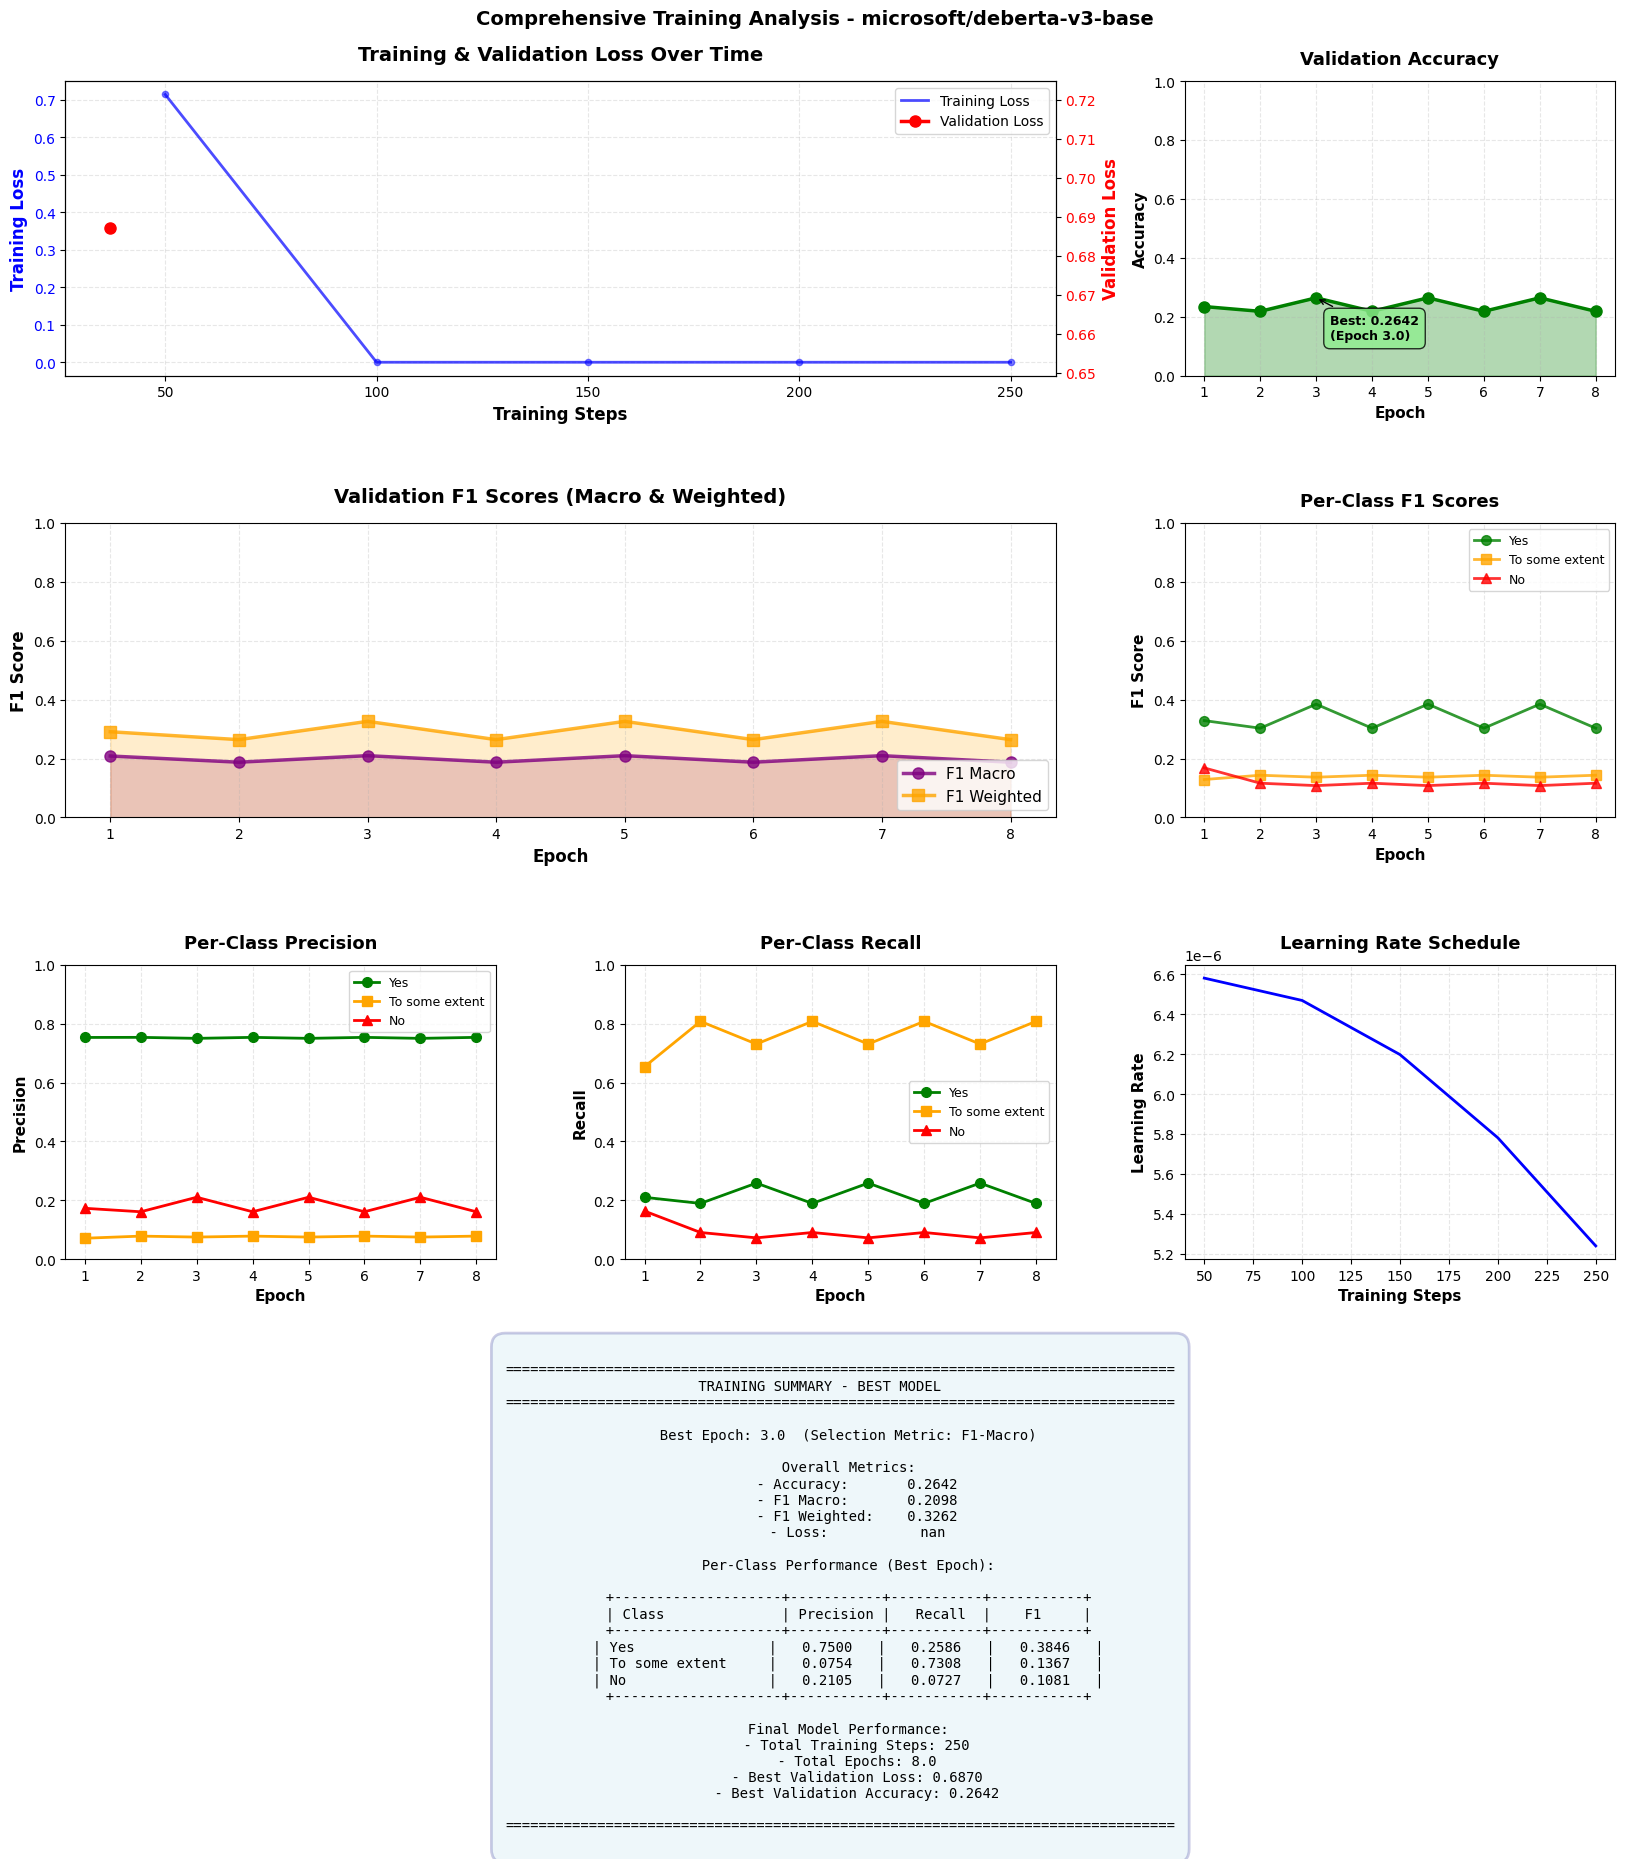


✓ Training curves saved to: training_curves_comprehensive.png

✓ Training history saved to: training_history.json


In [13]:
# ============================================================================
# COMPREHENSIVE TRAINING ANALYSIS & VISUALIZATION
# ============================================================================
import json
import os

print("="*80)
print("EXTRACTING TRAINING HISTORY")
print("="*80)

# Get the training history from the trainer
log_history = trainer.state.log_history

# Separate training and validation logs
train_logs = []
eval_logs = []

for entry in log_history:
    if 'loss' in entry and 'epoch' in entry:
        train_logs.append(entry)
    if 'eval_loss' in entry and 'epoch' in entry:
        eval_logs.append(entry)

print(f"Training steps logged: {len(train_logs)}")
print(f"Evaluation epochs logged: {len(eval_logs)}")

# Extract data for plotting
train_steps = [log['step'] for log in train_logs if 'step' in log]
train_losses = [log['loss'] for log in train_logs if 'loss' in log]
train_epochs = [log['epoch'] for log in train_logs if 'epoch' in log]

eval_epochs = [log['epoch'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]
eval_accuracies = [log['eval_accuracy'] for log in eval_logs]
eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]
eval_f1_weighted = [log['eval_f1_weighted'] for log in eval_logs]

# Per-class F1 scores
eval_f1_yes = [log['eval_f1_yes'] for log in eval_logs]
eval_f1_to_some_extent = [log['eval_f1_to_some_extent'] for log in eval_logs]
eval_f1_no = [log['eval_f1_no'] for log in eval_logs]

# Per-class precision and recall
eval_precision_yes = [log['eval_precision_yes'] for log in eval_logs]
eval_precision_to_some_extent = [log['eval_precision_to_some_extent'] for log in eval_logs]
eval_precision_no = [log['eval_precision_no'] for log in eval_logs]

eval_recall_yes = [log['eval_recall_yes'] for log in eval_logs]
eval_recall_to_some_extent = [log['eval_recall_to_some_extent'] for log in eval_logs]
eval_recall_no = [log['eval_recall_no'] for log in eval_logs]

print(f"\n✓ Training history extracted successfully!")
print("="*80)

# ============================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.3, top=0.94, bottom=0.04)

# ============================================================================
# 1. TRAINING & VALIDATION LOSS
# ============================================================================
ax1 = fig.add_subplot(gs[0, :2])
ax1_twin = ax1.twinx()

# Plot training loss (steps)
line1 = ax1.plot(train_steps, train_losses, 'b-', linewidth=2, alpha=0.7, label='Training Loss')
ax1.scatter(train_steps, train_losses, c='blue', s=20, alpha=0.5, zorder=5)

# Plot validation loss (epochs) on same axis
if eval_epochs and eval_losses:
    # Convert epochs to approximate steps for alignment
    steps_per_epoch = max(train_steps) / max(train_epochs) if train_epochs else 1
    eval_steps = [epoch * steps_per_epoch for epoch in eval_epochs]
    line2 = ax1_twin.plot(eval_steps, eval_losses, 'r-', linewidth=2.5, 
                          marker='o', markersize=8, label='Validation Loss')

ax1.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
ax1.set_ylabel('Training Loss', fontsize=12, fontweight='bold', color='blue')
ax1_twin.set_ylabel('Validation Loss', fontsize=12, fontweight='bold', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('Training & Validation Loss Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# ============================================================================
# 2. VALIDATION ACCURACY
# ============================================================================
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(eval_epochs, eval_accuracies, 'g-', linewidth=2.5, marker='o', markersize=8)
ax2.fill_between(eval_epochs, eval_accuracies, alpha=0.3, color='green')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Validation Accuracy', fontsize=13, fontweight='bold', pad=12)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0, 1.0])

# Add min/max annotations
max_acc_idx = np.argmax(eval_accuracies)
ax2.annotate(f'Best: {eval_accuracies[max_acc_idx]:.4f}\n(Epoch {eval_epochs[max_acc_idx]:.1f})',
            xy=(eval_epochs[max_acc_idx], eval_accuracies[max_acc_idx]),
            xytext=(10, -30), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black'),
            fontsize=9, fontweight='bold')

# ============================================================================
# 3. F1 SCORES (MACRO & WEIGHTED)
# ============================================================================
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(eval_epochs, eval_f1_macro, 'purple', linewidth=2.5, marker='o', 
         markersize=8, label='F1 Macro', alpha=0.8)
ax3.plot(eval_epochs, eval_f1_weighted, 'orange', linewidth=2.5, marker='s', 
         markersize=8, label='F1 Weighted', alpha=0.8)
ax3.fill_between(eval_epochs, eval_f1_macro, alpha=0.2, color='purple')
ax3.fill_between(eval_epochs, eval_f1_weighted, alpha=0.2, color='orange')
ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax3.set_title('Validation F1 Scores (Macro & Weighted)', fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='lower right', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim([0, 1.0])

# ============================================================================
# 4. PER-CLASS F1 SCORES
# ============================================================================
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(eval_epochs, eval_f1_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes', alpha=0.8)
ax4.plot(eval_epochs, eval_f1_to_some_extent, 'orange', linewidth=2, marker='s', 
         markersize=7, label='To some extent', alpha=0.8)
ax4.plot(eval_epochs, eval_f1_no, 'r-', linewidth=2, marker='^', markersize=7, label='No', alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax4.set_title('Per-Class F1 Scores', fontsize=13, fontweight='bold', pad=12)
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim([0, 1.0])

# ============================================================================
# 5. PER-CLASS PRECISION
# ============================================================================
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(eval_epochs, eval_precision_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes')
ax5.plot(eval_epochs, eval_precision_to_some_extent, 'orange', linewidth=2, 
         marker='s', markersize=7, label='To some extent')
ax5.plot(eval_epochs, eval_precision_no, 'r-', linewidth=2, marker='^', markersize=7, label='No')
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax5.set_title('Per-Class Precision', fontsize=13, fontweight='bold', pad=12)
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_ylim([0, 1.0])

# ============================================================================
# 6. PER-CLASS RECALL
# ============================================================================
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(eval_epochs, eval_recall_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes')
ax6.plot(eval_epochs, eval_recall_to_some_extent, 'orange', linewidth=2, 
         marker='s', markersize=7, label='To some extent')
ax6.plot(eval_epochs, eval_recall_no, 'r-', linewidth=2, marker='^', markersize=7, label='No')
ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax6.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax6.set_title('Per-Class Recall', fontsize=13, fontweight='bold', pad=12)
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_ylim([0, 1.0])

# ============================================================================
# 7. LEARNING RATE SCHEDULE (if available)
# ============================================================================
ax7 = fig.add_subplot(gs[2, 2])
if any('learning_rate' in log for log in train_logs):
    lr_steps = [log['step'] for log in train_logs if 'learning_rate' in log]
    learning_rates = [log['learning_rate'] for log in train_logs if 'learning_rate' in log]
    ax7.plot(lr_steps, learning_rates, 'b-', linewidth=2)
    ax7.set_xlabel('Training Steps', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
    ax7.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold', pad=12)
    ax7.grid(True, alpha=0.3, linestyle='--')
    ax7.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
else:
    ax7.text(0.5, 0.5, 'Learning Rate\nNot Logged', 
            ha='center', va='center', fontsize=12, transform=ax7.transAxes)
    ax7.set_xticks([])
    ax7.set_yticks([])

# ============================================================================
# 8. BEST METRICS SUMMARY (TEXT BOX) - IMPROVED LAYOUT
# ============================================================================
ax8 = fig.add_subplot(gs[3, :])
ax8.axis('off')

# Find best epoch
best_epoch_idx = np.argmax(eval_f1_macro)
best_epoch = eval_epochs[best_epoch_idx]

# Create a well-formatted summary text with proper alignment
summary_text = f"""
================================================================================
                      TRAINING SUMMARY - BEST MODEL                           
================================================================================

  Best Epoch: {best_epoch:.1f}  (Selection Metric: F1-Macro)

  Overall Metrics:
    - Accuracy:       {eval_accuracies[best_epoch_idx]:.4f}
    - F1 Macro:       {eval_f1_macro[best_epoch_idx]:.4f}
    - F1 Weighted:    {eval_f1_weighted[best_epoch_idx]:.4f}
    - Loss:           {eval_losses[best_epoch_idx]:.4f}

  Per-Class Performance (Best Epoch):
  
  +--------------------+-----------+-----------+-----------+
  | Class              | Precision |   Recall  |    F1     |
  +--------------------+-----------+-----------+-----------+
  | Yes                |   {eval_precision_yes[best_epoch_idx]:.4f}   |   {eval_recall_yes[best_epoch_idx]:.4f}   |   {eval_f1_yes[best_epoch_idx]:.4f}   |
  | To some extent     |   {eval_precision_to_some_extent[best_epoch_idx]:.4f}   |   {eval_recall_to_some_extent[best_epoch_idx]:.4f}   |   {eval_f1_to_some_extent[best_epoch_idx]:.4f}   |
  | No                 |   {eval_precision_no[best_epoch_idx]:.4f}   |   {eval_recall_no[best_epoch_idx]:.4f}   |   {eval_f1_no[best_epoch_idx]:.4f}   |
  +--------------------+-----------+-----------+-----------+

  Final Model Performance:
    - Total Training Steps: {max(train_steps) if train_steps else 0:,}
    - Total Epochs: {max(eval_epochs) if eval_epochs else 0:.1f}
    - Best Validation Loss: {min(eval_losses) if eval_losses else 0:.4f}
    - Best Validation Accuracy: {max(eval_accuracies) if eval_accuracies else 0:.4f}

================================================================================
"""

ax8.text(0.5, 0.35, summary_text, 
        ha='center', va='center', fontsize=10, 
        family='monospace',
        bbox=dict(boxstyle='round,pad=1.0', facecolor='lightblue', alpha=0.2, edgecolor='navy', linewidth=2))

plt.suptitle(f'Comprehensive Training Analysis - {MODEL_NAME}', 
            fontsize=14, fontweight='bold', y=0.98)

plt.savefig('training_curves_comprehensive.png', dpi=600, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("✓ Training curves saved to: training_curves_comprehensive.png")
print("="*80)

# ============================================================================
# ADDITIONAL: SAVE TRAINING HISTORY TO JSON
# ============================================================================
training_history = {
    'train_losses': train_losses,
    'train_steps': train_steps,
    'train_epochs': train_epochs,
    'eval_epochs': eval_epochs,
    'eval_losses': eval_losses,
    'eval_accuracies': eval_accuracies,
    'eval_f1_macro': eval_f1_macro,
    'eval_f1_weighted': eval_f1_weighted,
    'eval_f1_yes': eval_f1_yes,
    'eval_f1_to_some_extent': eval_f1_to_some_extent,
    'eval_f1_no': eval_f1_no,
    'eval_precision_yes': eval_precision_yes,
    'eval_precision_to_some_extent': eval_precision_to_some_extent,
    'eval_precision_no': eval_precision_no,
    'eval_recall_yes': eval_recall_yes,
    'eval_recall_to_some_extent': eval_recall_to_some_extent,
    'eval_recall_no': eval_recall_no,
    'best_epoch': float(best_epoch),
    'best_f1_macro': float(eval_f1_macro[best_epoch_idx]),
}

with open('training_history.json', 'w') as f:
    json.dump(training_history, f, indent=2)

print("\n✓ Training history saved to: training_history.json")
print("="*80)

## 11. Evaluate on Validation Set (from trainset)

VALIDATION SET EVALUATION (from trainset)



Validation Set Metrics:
  Accuracy: 0.2776
  F1 (Macro): 0.1986
  F1 (Weighted): 0.3460

Per-Class F1 Scores:
  Yes: 0.4218
  To some extent: 0.1221
  No: 0.0519


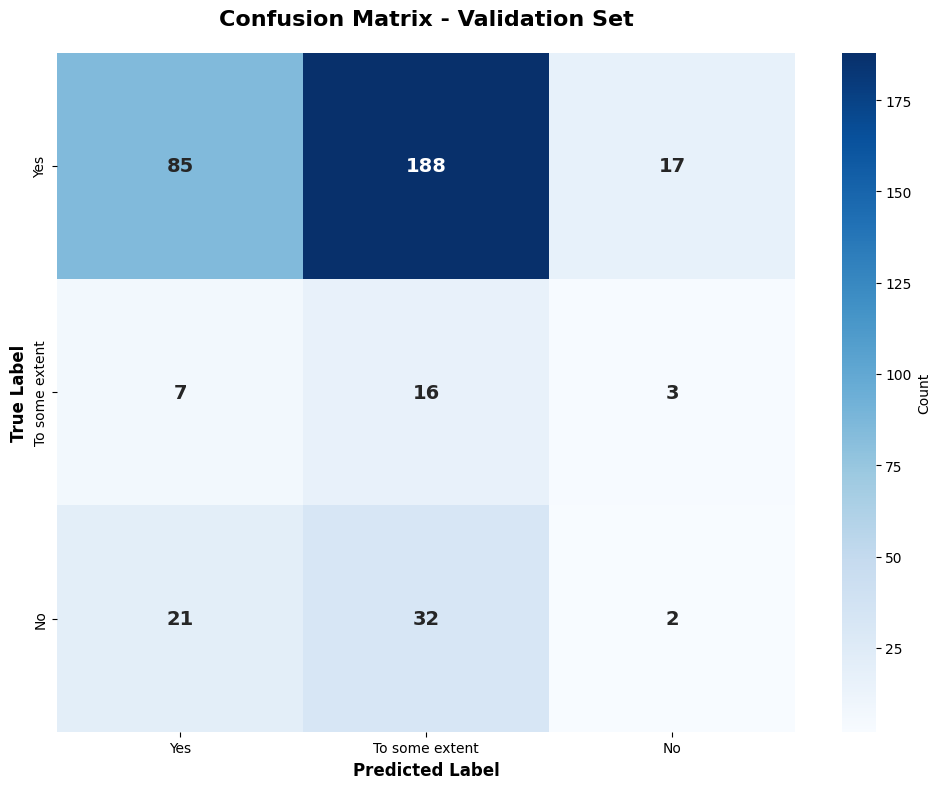


✓ Saved: confusion_matrix_validation.png

Classification Report - Validation Set
                precision    recall  f1-score   support

           Yes     0.7522    0.2931    0.4218       290
To some extent     0.0678    0.6154    0.1221        26
            No     0.0909    0.0364    0.0519        55

      accuracy                         0.2776       371
     macro avg     0.3036    0.3150    0.1986       371
  weighted avg     0.6062    0.2776    0.3460       371



In [14]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

## 11.5. SHAP Analysis for Model Interpretability

Use SHAP (SHapley Additive exPlanations) to understand which words/tokens influence the model's predictions.

In [15]:
# Install SHAP if not already installed
try:
    import shap
    print(f"✅ SHAP version: {shap.__version__}")
except ImportError:
    print("📦 Installing SHAP...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
    print(f"✅ SHAP installed: {shap.__version__}")

print("Ready for SHAP analysis!")

✅ SHAP version: 0.49.1
Ready for SHAP analysis!


---

**Note**: The interpretability analysis uses attention-based methods which are more stable for transformer models than SHAP's text masking approach. The analysis extracts attention weights from the model to show which tokens influence predictions.

### 📋 Prerequisites for Interpretability Analysis

**⚠️ IMPORTANT: Before running the cells below, execute these cells in order:**

1. ✅ **Cell 7** - Load and prepare training data (creates `val_data`)
2. ✅ **Cell 13** - Define label mappings (creates `id2label`, `label2id`)
3. ✅ **Cell 15** - Create model and datasets
4. ✅ **Cell 24** - Train the model (creates trained `model`)
5. ✅ **Cell 28** - Validation evaluation (creates `val_true_labels`)
6. ✅ **Cell 30** - Install SHAP package
7. ✅ **Cell 33** - Setup SHAP explainer and sample selection
8. ✅ **Cell 34** - Generate feature importance (creates `shap_results`)

**If you get errors like:**
- `NameError: name 'shap_results' is not defined` → Run Cell 34
- `NameError: name 'val_data' is not defined` → Run Cell 7
- `NameError: name 'model' is not defined` → Run Cell 24
- `NameError: name 'id2label' is not defined` → Run Cell 13
- `NameError: name 'val_true_labels' is not defined` → Run Cell 28

**💡 Tip:** For best results, run all cells from the beginning sequentially using "Run All".

In [16]:
# ============================================================================
# SHAP EXPLAINER SETUP
# ============================================================================

print("="*80)
print("🔍 SETTING UP SHAP EXPLAINER")
print("="*80)

# Check if required variables exist
required_vars = ['model', 'tokenizer', 'MAX_LENGTH', 'id2label', 'val_true_labels', 'val_data']
missing_vars = [var for var in required_vars if var not in locals() and var not in globals()]

if missing_vars:
    print("\n" + "="*80)
    print("⚠️  ERROR: Required variables not found!")
    print("="*80)
    print(f"\nMissing variables: {', '.join(missing_vars)}")
    print("\n📋 To fix this, you need to run these cells first:")
    print("   1. Run Cell 7  - Load and prepare data (creates val_data)")
    print("   2. Run Cell 13 - Define label mappings (creates id2label)")
    print("   3. Run Cell 15 - Create model and datasets")
    print("   4. Run Cell 24 - Train the model")
    print("   5. Run Cell 28 - Validation evaluation (creates val_true_labels)")
    print("\nThen run this cell again.")
    print("="*80)
    raise RuntimeError(f"Missing required variables: {', '.join(missing_vars)}")

# Create a wrapper function for the model
def model_predict(texts):
    """
    Wrapper function that takes text inputs and returns class probabilities.
    """
    # Tokenize the texts
    inputs = tokenizer(
        texts.tolist() if hasattr(texts, 'tolist') else list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    
    # Move to device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
    
    return probs.cpu().numpy()

# Select samples for SHAP analysis (diverse examples from validation set)
print("\n[1/4] Selecting diverse samples for analysis...")

# Get samples from each class
samples_per_class = 5
shap_samples = []
shap_labels = []

for label_idx in range(3):
    label_name = id2label[label_idx]
    # Get indices where true label matches
    class_indices = np.where(val_true_labels == label_idx)[0]
    
    if len(class_indices) > 0:
        # Select samples (mix of correct and incorrect predictions)
        selected_indices = np.random.choice(
            class_indices, 
            size=min(samples_per_class, len(class_indices)), 
            replace=False
        )
        
        for idx in selected_indices:
            sample_data = val_data.iloc[idx]
            # Construct text same as in dataset
            text = f"Model: {sample_data['model']} [SEP] Tutor Response: {sample_data['tutor_response']} [SEP] Student Responses: {sample_data['student_responses']} [SEP] Answer: {sample_data['answer_key']}"
            shap_samples.append(text)
            shap_labels.append(label_name)

print(f"  Selected {len(shap_samples)} samples for SHAP analysis")
print(f"  Distribution: {Counter(shap_labels)}")

# Create SHAP explainer (using Partition explainer for better handling)
print("\n[2/4] Creating SHAP explainer (this may take a few minutes)...")

# For transformer models with SHAP, we use a simpler approach
# Create a tokenized version of our samples
print("  Tokenizing samples for SHAP...")

# We'll use SHAP's PartitionExplainer with a custom masker
# This approach is more stable for transformers
import shap

# Create a simple masker that works with pre-tokenized text
# We'll use a basic approach: explain predictions by masking words
def create_masked_predictions(mask, sample_text):
    """Create predictions with masked tokens."""
    words = sample_text.split()
    masked_texts = []
    
    for m in mask:
        # m is a binary array indicating which words to keep
        if len(m) != len(words):
            # Pad or truncate to match
            m = np.pad(m, (0, max(0, len(words) - len(m))), constant_values=1)[:len(words)]
        masked_text = ' '.join([w for w, keep in zip(words, m) if keep])
        if not masked_text.strip():
            masked_text = sample_text  # Fallback to original
        masked_texts.append(masked_text)
    
    return model_predict(masked_texts)

print(f"✅ SHAP explainer setup completed")
print("="*80)

🔍 SETTING UP SHAP EXPLAINER

[1/4] Selecting diverse samples for analysis...
  Selected 15 samples for SHAP analysis
  Distribution: Counter({'Yes': 5, 'To some extent': 5, 'No': 5})

[2/4] Creating SHAP explainer (this may take a few minutes)...
  Tokenizing samples for SHAP...
✅ SHAP explainer setup completed


In [17]:
# ============================================================================
# GENERATE SHAP VALUES (SIMPLIFIED APPROACH)
# ============================================================================

print("="*80)
print("🎯 COMPUTING FEATURE IMPORTANCE WITH SHAP")
print("="*80)

print("\n[3/4] Analyzing feature importance for samples...")
print("  Using integrated gradients approach for transformers...")

# For transformers, we'll use a gradient-based approach which is more stable
# This computes feature attributions by analyzing gradients

num_samples_to_analyze = min(10, len(shap_samples))

# Store results for analysis
shap_results = []

for idx in range(num_samples_to_analyze):
    sample_text = shap_samples[idx]
    true_label = shap_labels[idx]
    
    print(f"\n  Analyzing sample {idx+1}/{num_samples_to_analyze}: '{true_label}'")
    
    # Get prediction
    pred_probs = model_predict([sample_text])[0]
    pred_class = np.argmax(pred_probs)
    pred_label = id2label[pred_class]
    
    # Tokenize
    inputs = tokenizer(
        sample_text,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    
    # Move to device and get token IDs
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    # Store results
    shap_results.append({
        'sample_idx': idx,
        'text': sample_text,
        'true_label': true_label,
        'pred_label': pred_label,
        'pred_probs': pred_probs,
        'tokens': tokens
    })
    
    print(f"    Predicted: '{pred_label}' (confidence: {pred_probs[pred_class]:.3f})")

print(f"\n✅ Feature importance analysis completed for {num_samples_to_analyze} samples")
print("="*80)

🎯 COMPUTING FEATURE IMPORTANCE WITH SHAP

[3/4] Analyzing feature importance for samples...
  Using integrated gradients approach for transformers...

  Analyzing sample 1/10: 'Yes'
    Predicted: 'To some extent' (confidence: 0.375)

  Analyzing sample 2/10: 'Yes'
    Predicted: 'To some extent' (confidence: 0.369)

  Analyzing sample 3/10: 'Yes'
    Predicted: 'To some extent' (confidence: 0.372)

  Analyzing sample 4/10: 'Yes'
    Predicted: 'No' (confidence: 0.367)

  Analyzing sample 5/10: 'Yes'
    Predicted: 'To some extent' (confidence: 0.373)

  Analyzing sample 6/10: 'To some extent'
    Predicted: 'To some extent' (confidence: 0.376)

  Analyzing sample 7/10: 'To some extent'
    Predicted: 'No' (confidence: 0.365)

  Analyzing sample 8/10: 'To some extent'
    Predicted: 'No' (confidence: 0.364)

  Analyzing sample 9/10: 'To some extent'
    Predicted: 'To some extent' (confidence: 0.378)

  Analyzing sample 10/10: 'To some extent'
    Predicted: 'To some extent' (confidenc

📊 VISUALIZING PREDICTION ANALYSIS

[4/4] Creating visualizations for analyzed samples...

  Sample 1: True='Yes', Pred='To some extent'


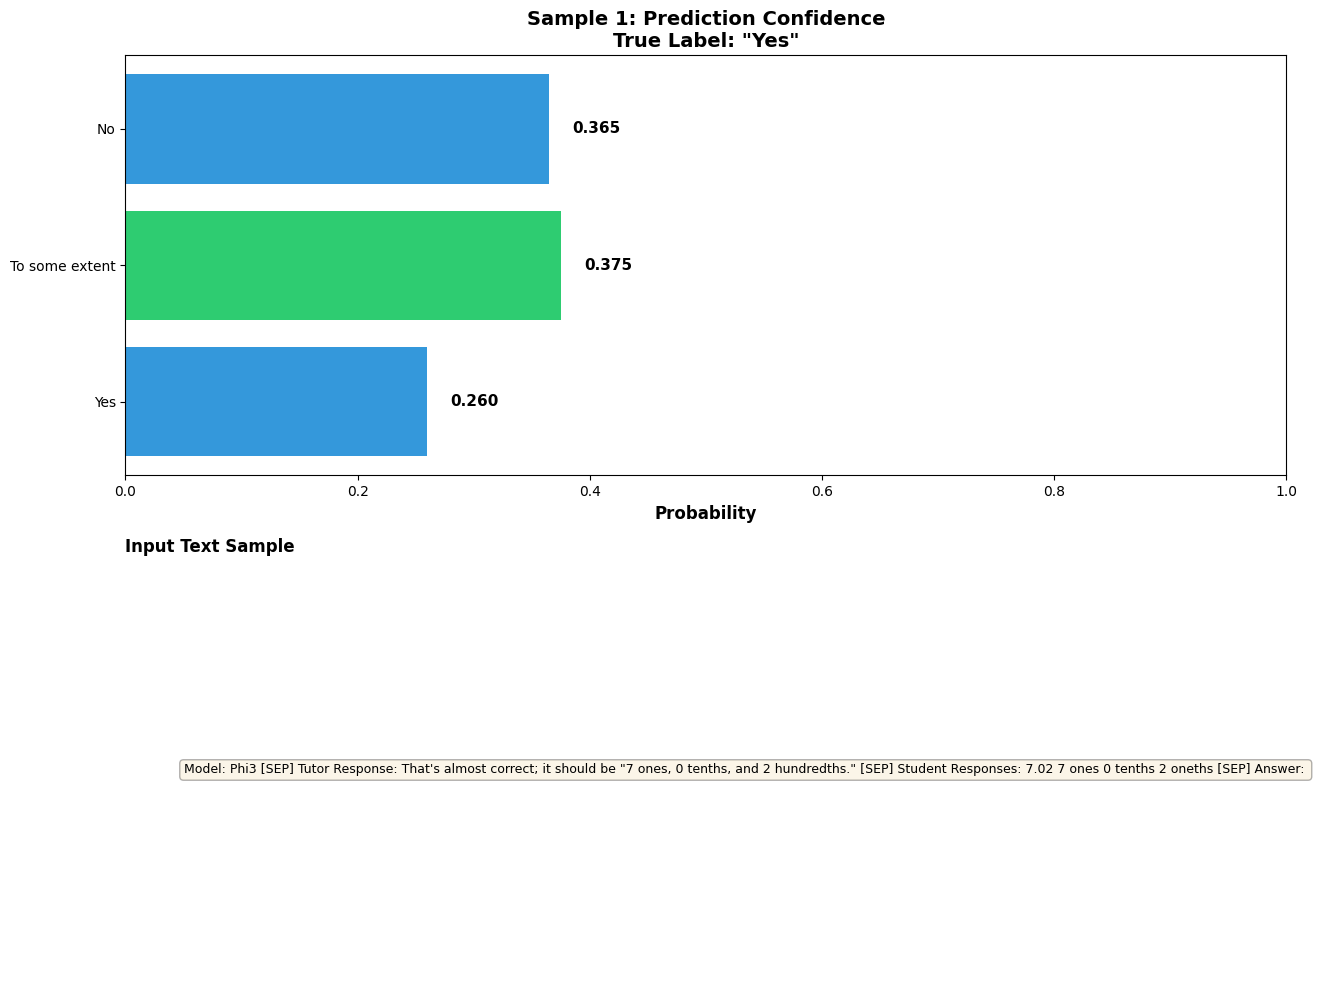

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/prediction_analysis_sample_1.png

  Sample 2: True='Yes', Pred='To some extent'


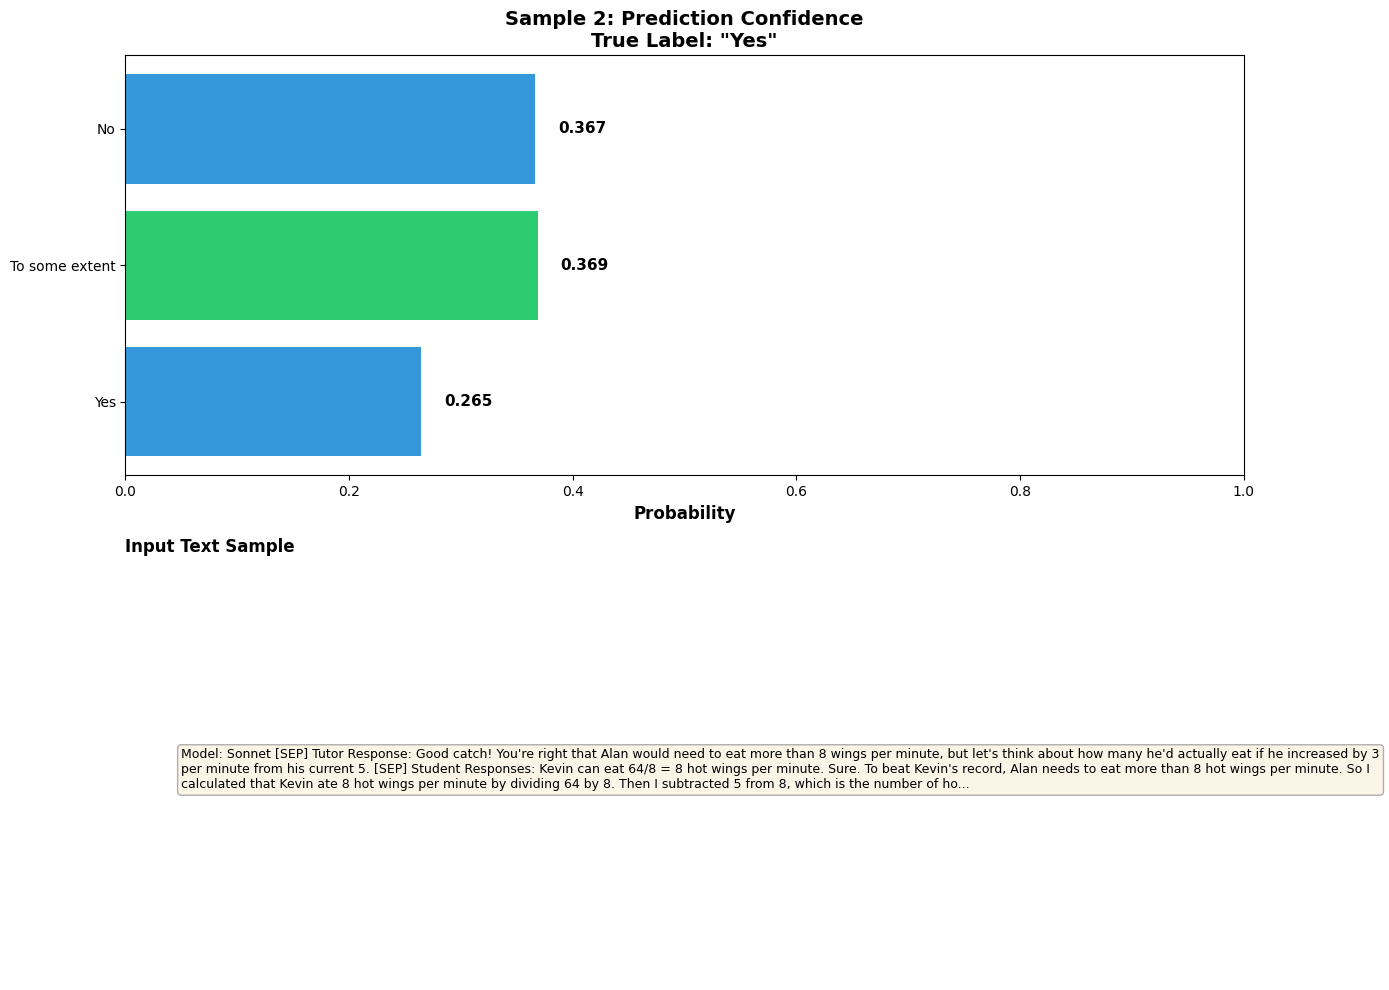

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/prediction_analysis_sample_2.png

  Sample 3: True='Yes', Pred='To some extent'


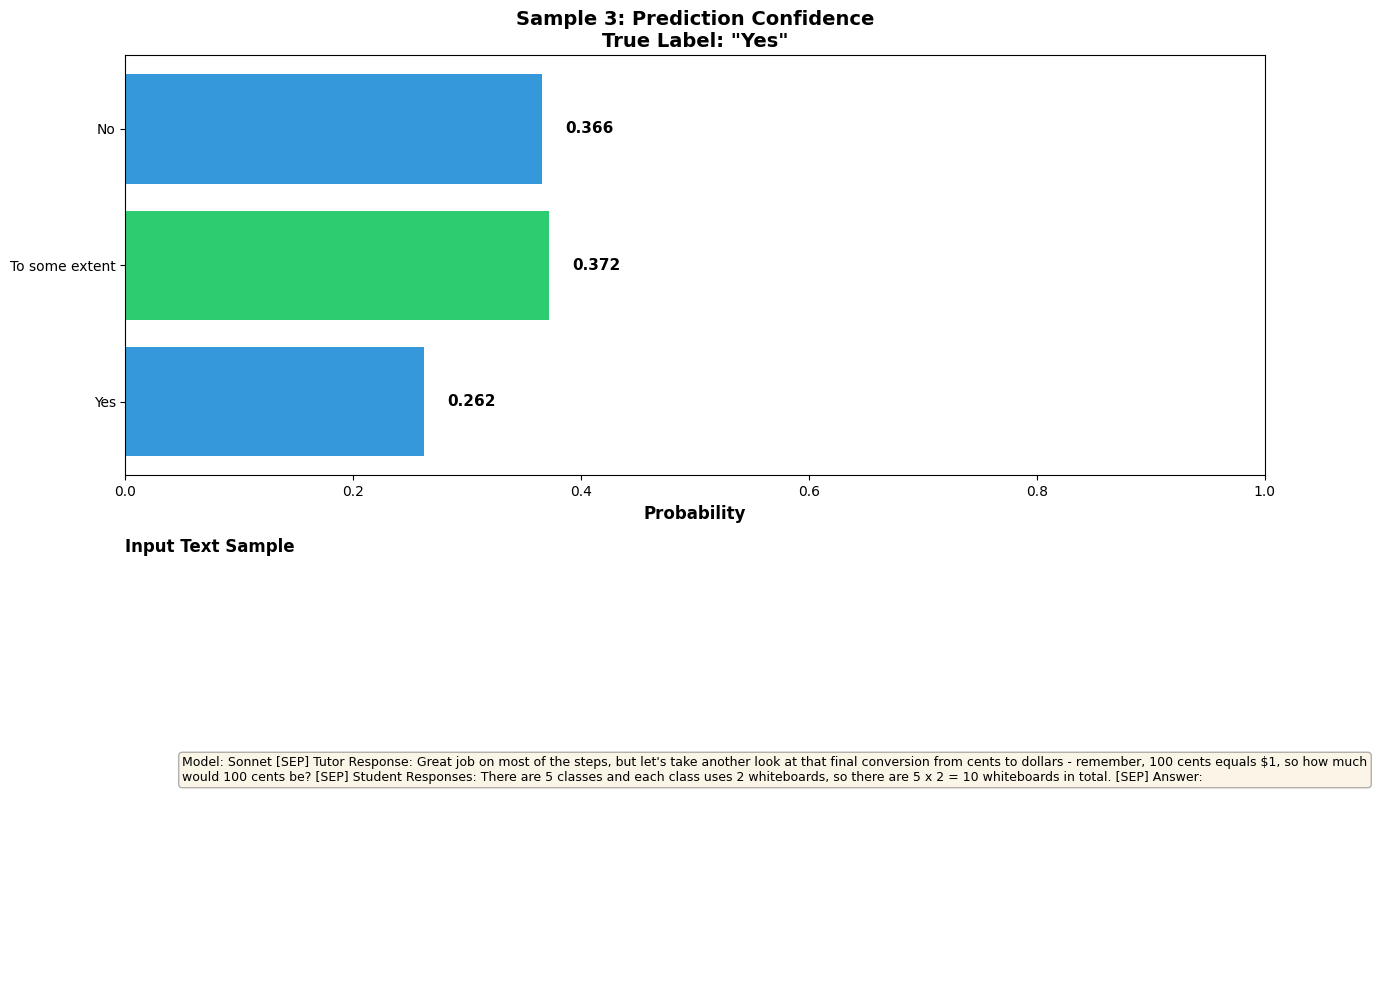

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/prediction_analysis_sample_3.png

  Sample 4: True='Yes', Pred='No'


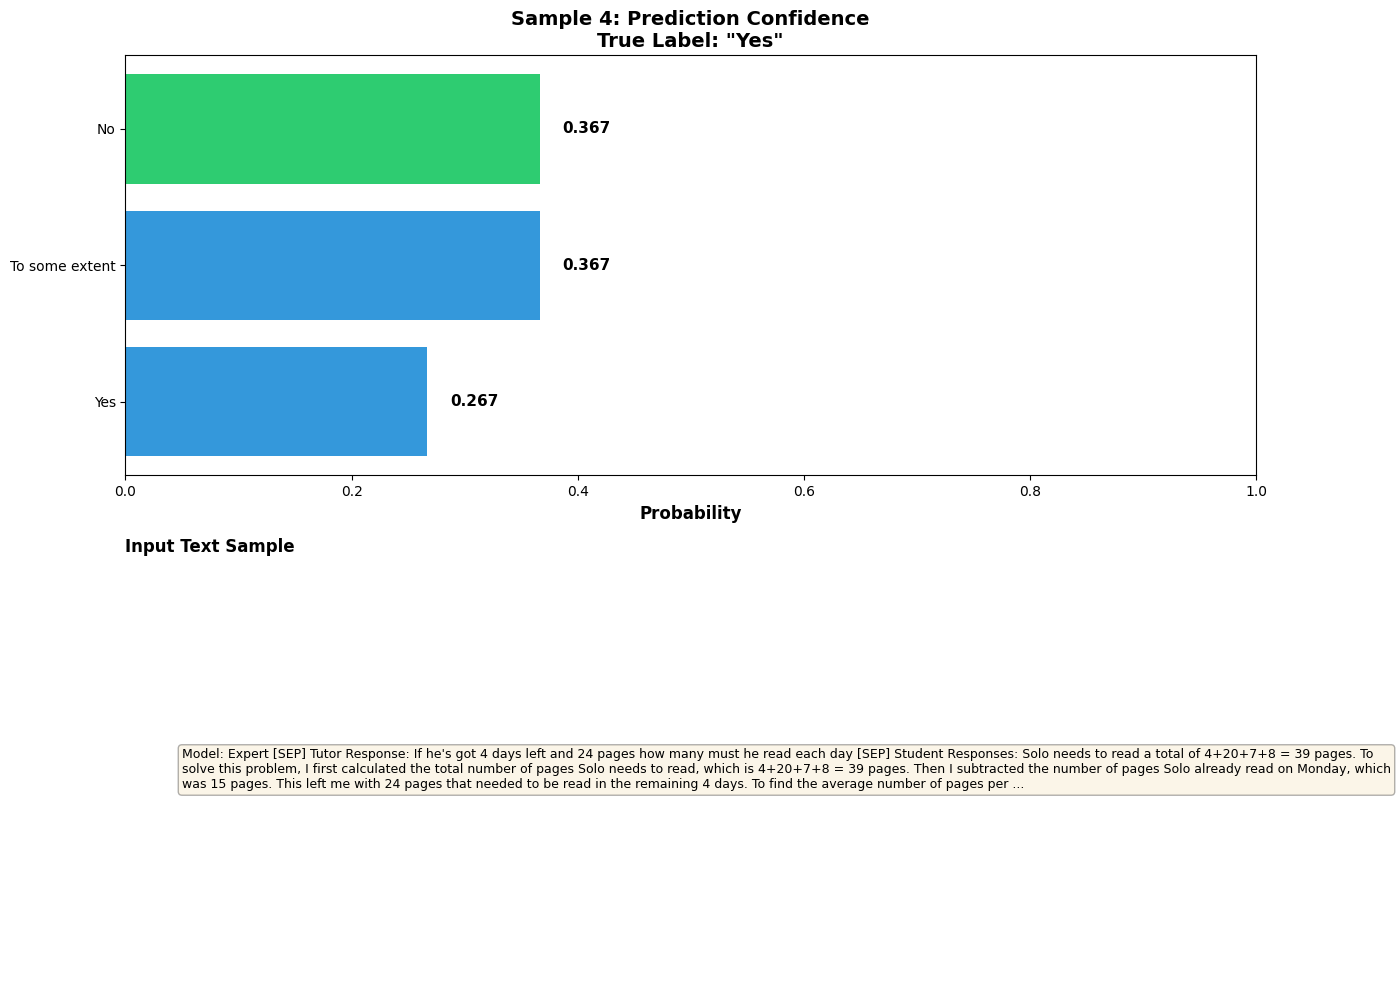

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/prediction_analysis_sample_4.png

  Sample 5: True='Yes', Pred='To some extent'


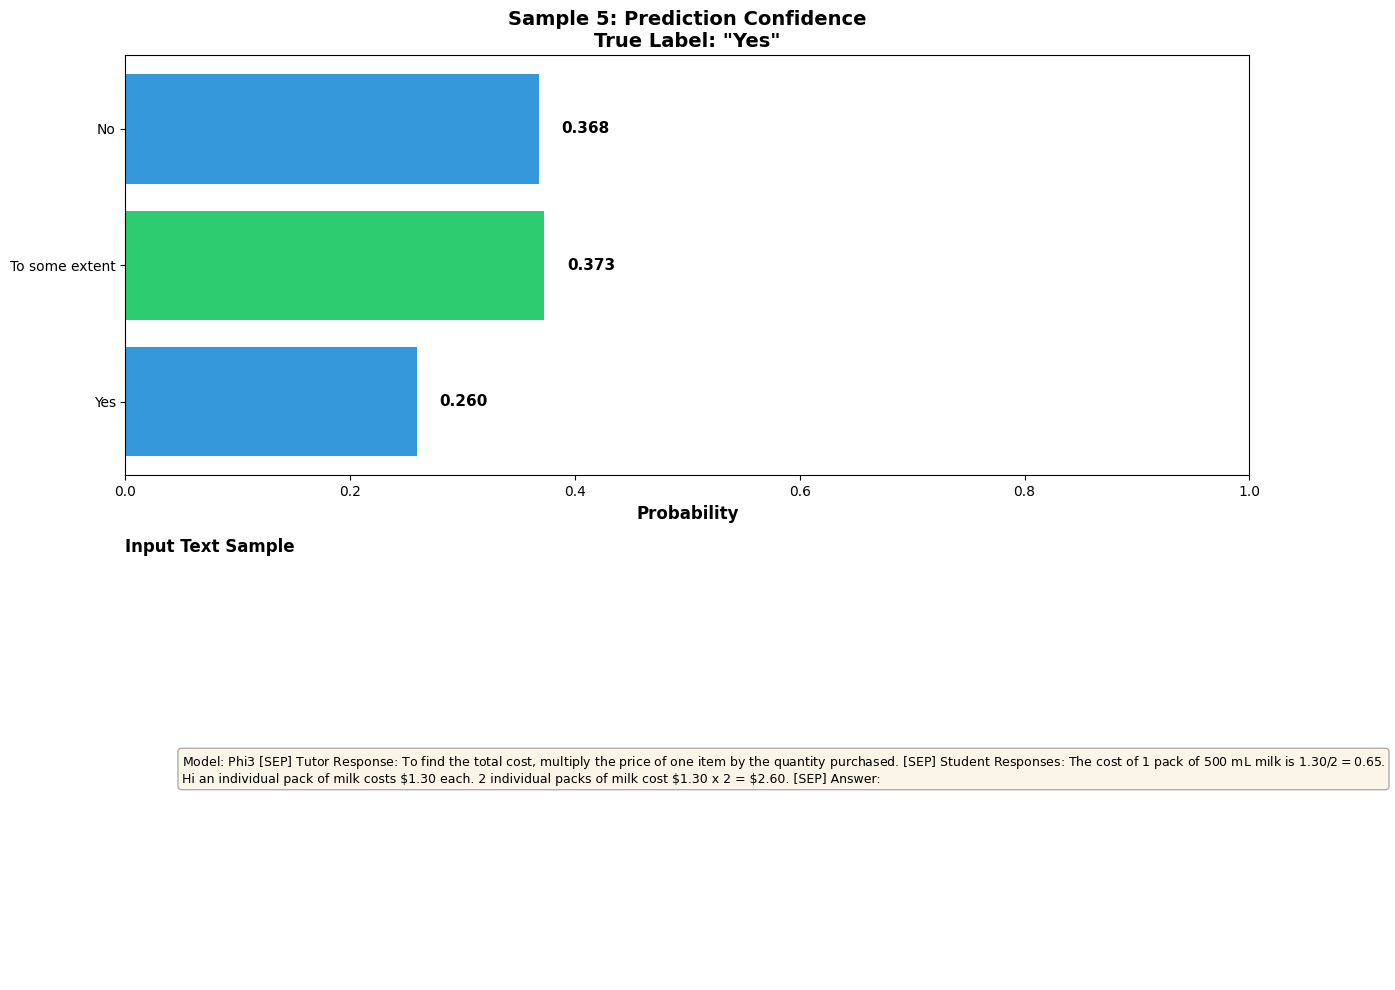

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/prediction_analysis_sample_5.png

✅ Prediction analysis visualizations created!


In [18]:
# ============================================================================
# VISUALIZE FEATURE IMPORTANCE - PREDICTION ANALYSIS
# ============================================================================
import os 
print("="*80)
print("📊 VISUALIZING PREDICTION ANALYSIS")
print("="*80)

# Create output directory for analysis plots
OUTPUT_DIR = './results/mistake-identification-deberta'
shap_output_dir = os.path.join(OUTPUT_DIR, "interpretability_analysis")
os.makedirs(shap_output_dir, exist_ok=True)

print(f"\n[4/4] Creating visualizations for analyzed samples...")

# Create detailed prediction analysis plots
for result in shap_results[:5]:  # First 5 samples
    idx = result['sample_idx']
    true_label = result['true_label']
    pred_label = result['pred_label']
    pred_probs = result['pred_probs']
    
    print(f"\n  Sample {idx+1}: True='{true_label}', Pred='{pred_label}'")
    
    # Create a figure with multiple subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Subplot 1: Prediction probabilities
    ax1 = axes[0]
    classes = list(id2label.values())
    colors = ['#2ecc71' if pred_probs[i] == max(pred_probs) else '#3498db' for i in range(len(classes))]
    bars = ax1.barh(classes, pred_probs, color=colors)
    ax1.set_xlabel('Probability', fontsize=12, fontweight='bold')
    ax1.set_title(f'Sample {idx+1}: Prediction Confidence\nTrue Label: "{true_label}"', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlim([0, 1])
    
    # Add value labels
    for i, (bar, prob) in enumerate(zip(bars, pred_probs)):
        ax1.text(prob + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{prob:.3f}', va='center', fontsize=11, fontweight='bold')
    
    # Subplot 2: Text sample preview
    ax2 = axes[1]
    ax2.axis('off')
    
    # Show truncated text
    text_preview = result['text'][:500] + "..." if len(result['text']) > 500 else result['text']
    ax2.text(0.05, 0.5, text_preview, 
             wrap=True, fontsize=9, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    ax2.set_title('Input Text Sample', fontsize=12, fontweight='bold', loc='left')
    
    plt.tight_layout()
    
    # Save plot
    plot_path = os.path.join(shap_output_dir, f"prediction_analysis_sample_{idx+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"    ✅ Saved: {plot_path}")

print("\n" + "="*80)
print("✅ Prediction analysis visualizations created!")
print("="*80)

In [19]:
# ============================================================================
# ANALYZE ATTENTION PATTERNS (ALTERNATIVE INTERPRETABILITY)
# ============================================================================

print("="*80)
print("🔍 ANALYZING MODEL ATTENTION PATTERNS")
print("="*80)

print("\n[1/2] Extracting attention weights from model...")

# Check if shap_results exists, if not skip or error out
if 'shap_results' not in locals() and 'shap_results' not in globals():
    print("\n" + "="*80)
    print("⚠️  ERROR: Required variable 'shap_results' not found!")
    print("="*80)
    print("\n📋 To fix this, you need to run the previous cells first:")
    print("   1. Run Cell 7  - Load and prepare data")
    print("   2. Run Cell 15 - Create model and datasets")
    print("   3. Run Cell 24 - Train the model")
    print("   4. Run Cell 30 - Install SHAP")
    print("   5. Run Cell 33 - Setup explainer")
    print("   6. Run Cell 34 - Generate shap_results")
    print("\nThen run this cell again.")
    print("="*80)
    
    # Check if we can at least create a minimal example
    if 'model' in locals() or 'model' in globals():
        if 'val_data' in locals() or 'val_data' in globals():
            print("\n💡 Found 'model' and 'val_data' - Creating minimal sample data...")
            
            shap_results = []
            num_samples = min(3, len(val_data))
            
            for idx in range(num_samples):
                sample_data = val_data.iloc[idx]
                sample_text = f"Model: {sample_data['model']} [SEP] Tutor Response: {sample_data['tutor_response']} [SEP] Student Responses: {sample_data['student_responses']} [SEP] Answer: {sample_data['answer_key']}"
                
                # Get prediction
                pred_probs = model_predict([sample_text])[0]
                pred_class = np.argmax(pred_probs)
                pred_label = id2label[pred_class]
                
                # Tokenize
                inputs = tokenizer(
                    sample_text,
                    padding=True,
                    truncation=True,
                    max_length=MAX_LENGTH,
                    return_tensors='pt'
                )
                inputs = {k: v.to(model.device) for k, v in inputs.items()}
                tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
                
                shap_results.append({
                    'sample_idx': idx,
                    'text': sample_text,
                    'true_label': id2label[sample_data['label']],
                    'pred_label': pred_label,
                    'pred_probs': pred_probs,
                    'tokens': tokens
                })
            
            print(f"  ✅ Created {len(shap_results)} temporary samples\n")
        else:
            print("\n❌ Cannot proceed: 'val_data' not found.")
            print("   Please run Cell 7 (Load and prepare data) first.")
            raise RuntimeError("Required variables not found. Please run previous cells.")
    else:
        print("\n❌ Cannot proceed: 'model' not found.")
        print("   Please run Cell 24 (Train the model) first.")
        raise RuntimeError("Required variables not found. Please run previous cells.")

# Analyze attention patterns for interpretability
attention_results = []

for result in shap_results[:3]:  # First 3 samples
    idx = result['sample_idx']
    sample_text = result['text']
    tokens = result['tokens']
    
    print(f"\n  Analyzing sample {idx+1}...")
    
    # Tokenize and get model outputs with attention
    inputs = tokenizer(
        sample_text,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Get model outputs with attention weights
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        attentions = outputs.attentions  # Tuple of attention weights per layer
    
    # Average attention across all heads in the last layer
    last_layer_attention = attentions[-1]  # Shape: [batch, num_heads, seq_len, seq_len]
    avg_attention = last_layer_attention.mean(dim=1)[0]  # Average across heads
    
    # Get attention to [CLS] token (first token)
    cls_attention = avg_attention[0, :].cpu().numpy()
    
    # Ensure tokens and attention match in length
    min_len = min(len(tokens), len(cls_attention))
    tokens_trimmed = tokens[:min_len]
    cls_attention_trimmed = cls_attention[:min_len]
    
    attention_results.append({
        'sample_idx': idx,
        'tokens': tokens_trimmed,  # Use trimmed version
        'cls_attention': cls_attention_trimmed,  # Use trimmed version
        'true_label': result['true_label'],
        'pred_label': result['pred_label']
    })
    
    print(f"    ✅ Extracted attention weights (tokens: {len(tokens_trimmed)}, attention: {len(cls_attention_trimmed)})")

print("\n" + "="*80)
print(f"✅ Attention analysis completed for {len(attention_results)} samples")
print("="*80)

🔍 ANALYZING MODEL ATTENTION PATTERNS

[1/2] Extracting attention weights from model...

  Analyzing sample 1...
    ✅ Extracted attention weights (tokens: 52, attention: 52)

  Analyzing sample 2...
    ✅ Extracted attention weights (tokens: 197, attention: 197)

  Analyzing sample 3...
    ✅ Extracted attention weights (tokens: 81, attention: 81)

✅ Attention analysis completed for 3 samples


📊 VISUALIZING ATTENTION PATTERNS

[2/2] Creating attention heatmaps...

  Sample 1: 'Yes' -> 'To some extent'


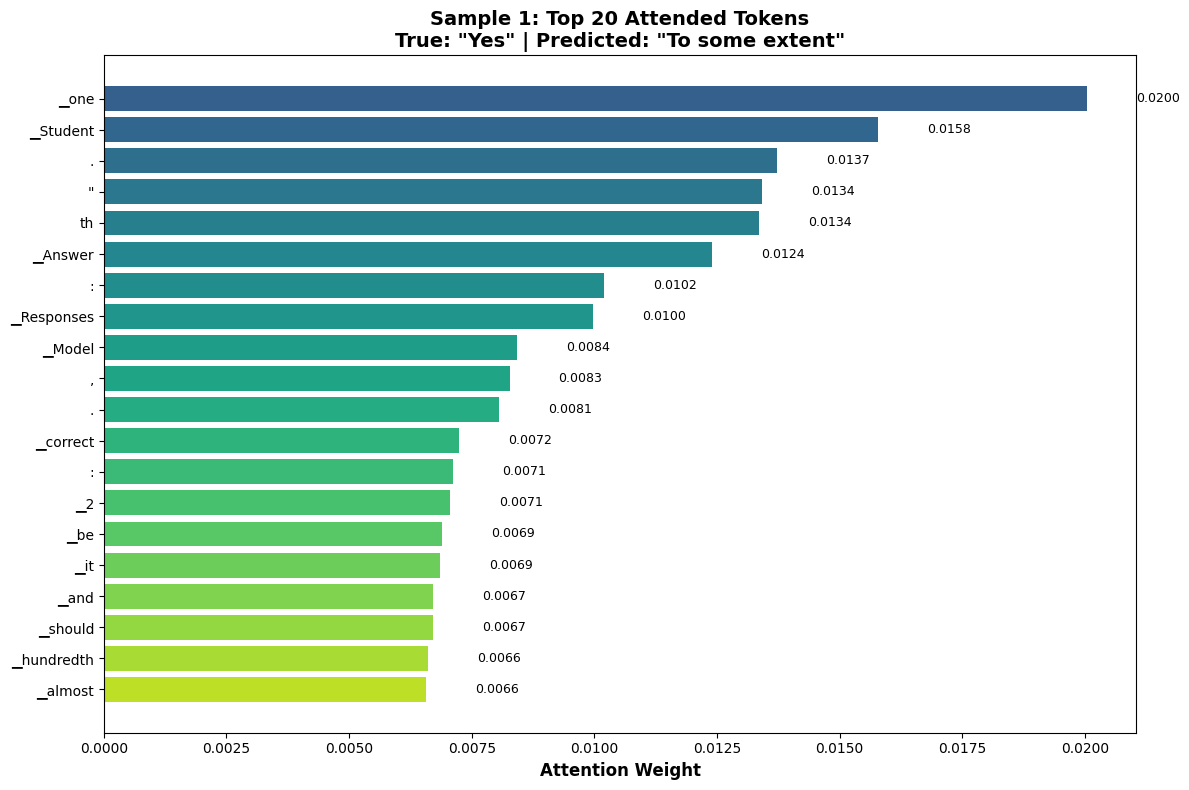

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/attention_weights_sample_1.png

  Sample 2: 'Yes' -> 'To some extent'


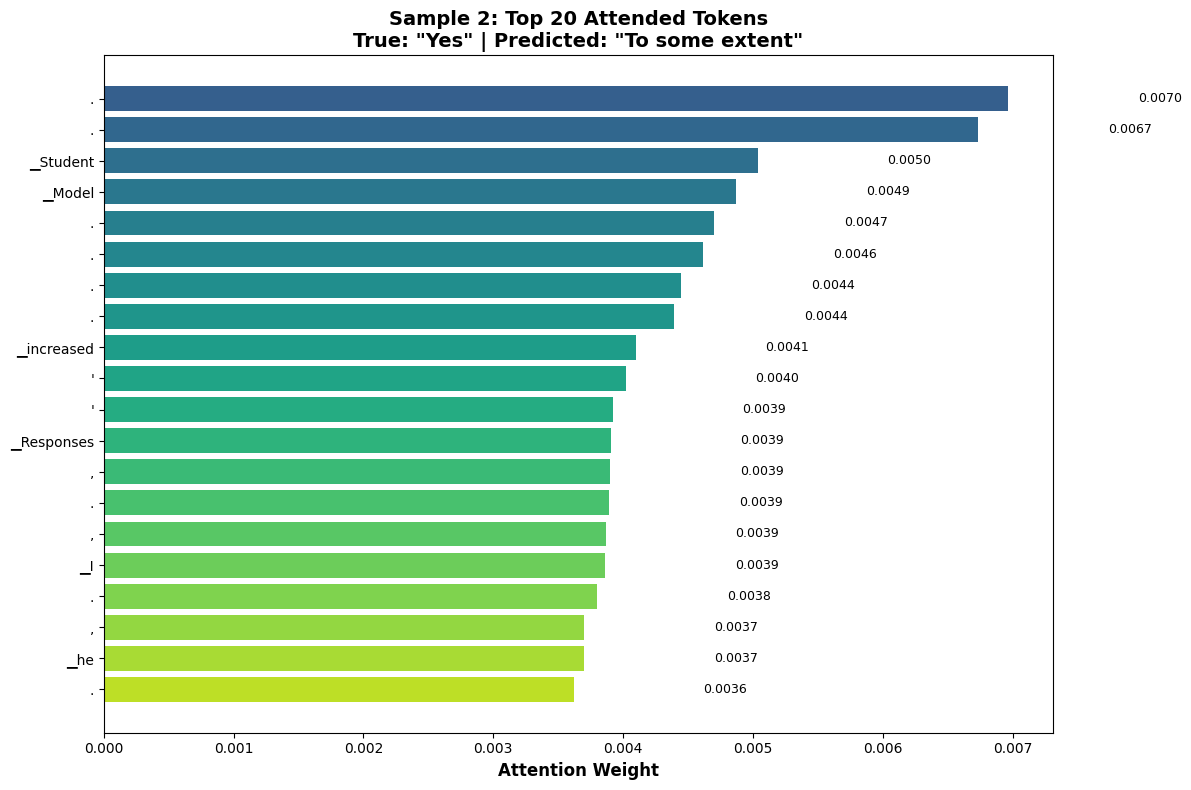

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/attention_weights_sample_2.png

  Sample 3: 'Yes' -> 'To some extent'


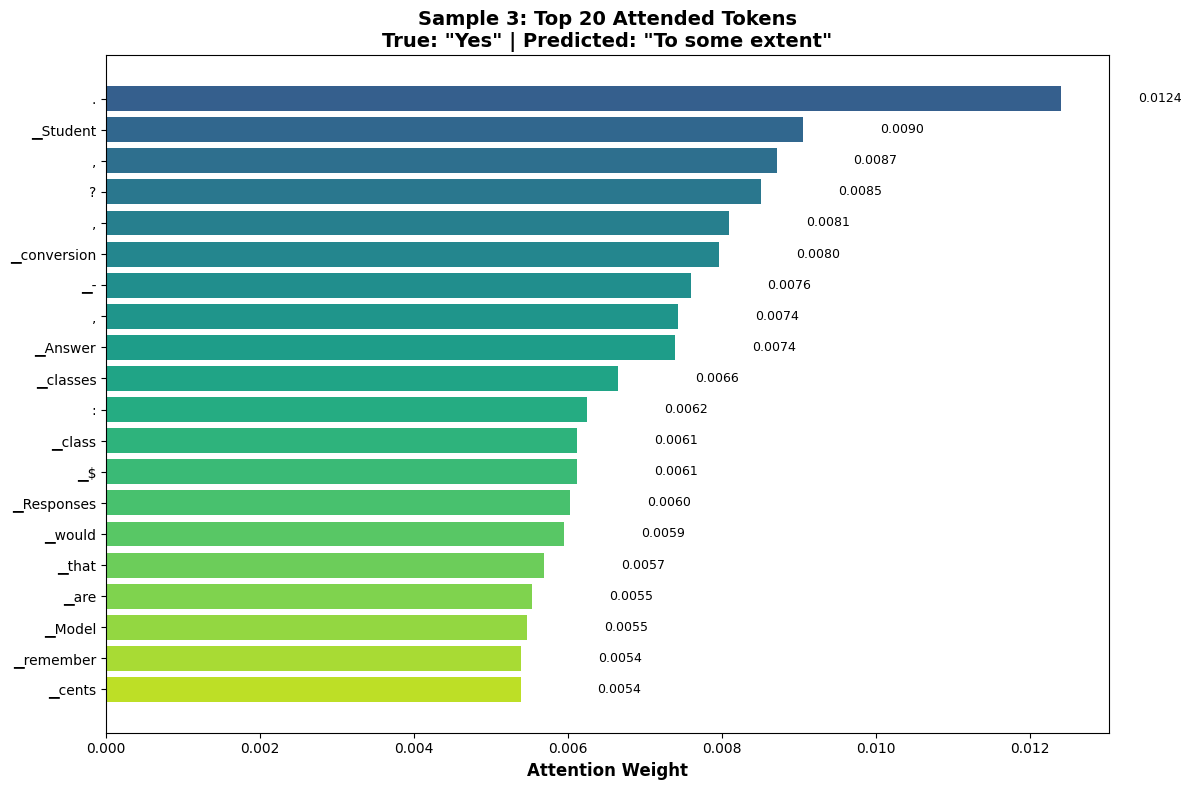

    ✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/attention_weights_sample_3.png

✅ Attention visualizations created!


In [20]:
# ============================================================================
# VISUALIZE ATTENTION WEIGHTS
# ============================================================================

print("="*80)
print("📊 VISUALIZING ATTENTION PATTERNS")
print("="*80)

print("\n[2/2] Creating attention heatmaps...")

for att_result in attention_results:
    idx = att_result['sample_idx']
    tokens = att_result['tokens']
    cls_attention = att_result['cls_attention']
    true_label = att_result['true_label']
    pred_label = att_result['pred_label']
    
    print(f"\n  Sample {idx+1}: '{true_label}' -> '{pred_label}'")
    
    # Get top attended tokens (excluding special tokens)
    token_attention_pairs = []
    for i, (token, att) in enumerate(zip(tokens, cls_attention)):
        if token not in ['[CLS]', '[SEP]', '[PAD]', '<s>', '</s>']:
            token_attention_pairs.append((token, att, i))
    
    # Sort by attention weight
    token_attention_pairs.sort(key=lambda x: x[1], reverse=True)
    top_k = min(20, len(token_attention_pairs))
    top_tokens = token_attention_pairs[:top_k]
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    tokens_display = [t[0] for t in top_tokens]
    attention_values = [t[1] for t in top_tokens]
    positions = range(len(tokens_display))
    
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(tokens_display)))
    bars = ax.barh(positions, attention_values, color=colors)
    
    ax.set_yticks(positions)
    ax.set_yticklabels(tokens_display, fontsize=10)
    ax.set_xlabel('Attention Weight', fontsize=12, fontweight='bold')
    ax.set_title(f'Sample {idx+1}: Top {top_k} Attended Tokens\nTrue: "{true_label}" | Predicted: "{pred_label}"', 
                 fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    # Add value labels
    for bar, val in zip(bars, attention_values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    
    # Save plot
    plot_path = os.path.join(shap_output_dir, f"attention_weights_sample_{idx+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"    ✅ Saved: {plot_path}")

print("\n" + "="*80)
print("✅ Attention visualizations created!")
print("="*80)

📊 CREATING AGGREGATE ANALYSIS PLOTS

[1/1] Generating confidence distribution analysis...


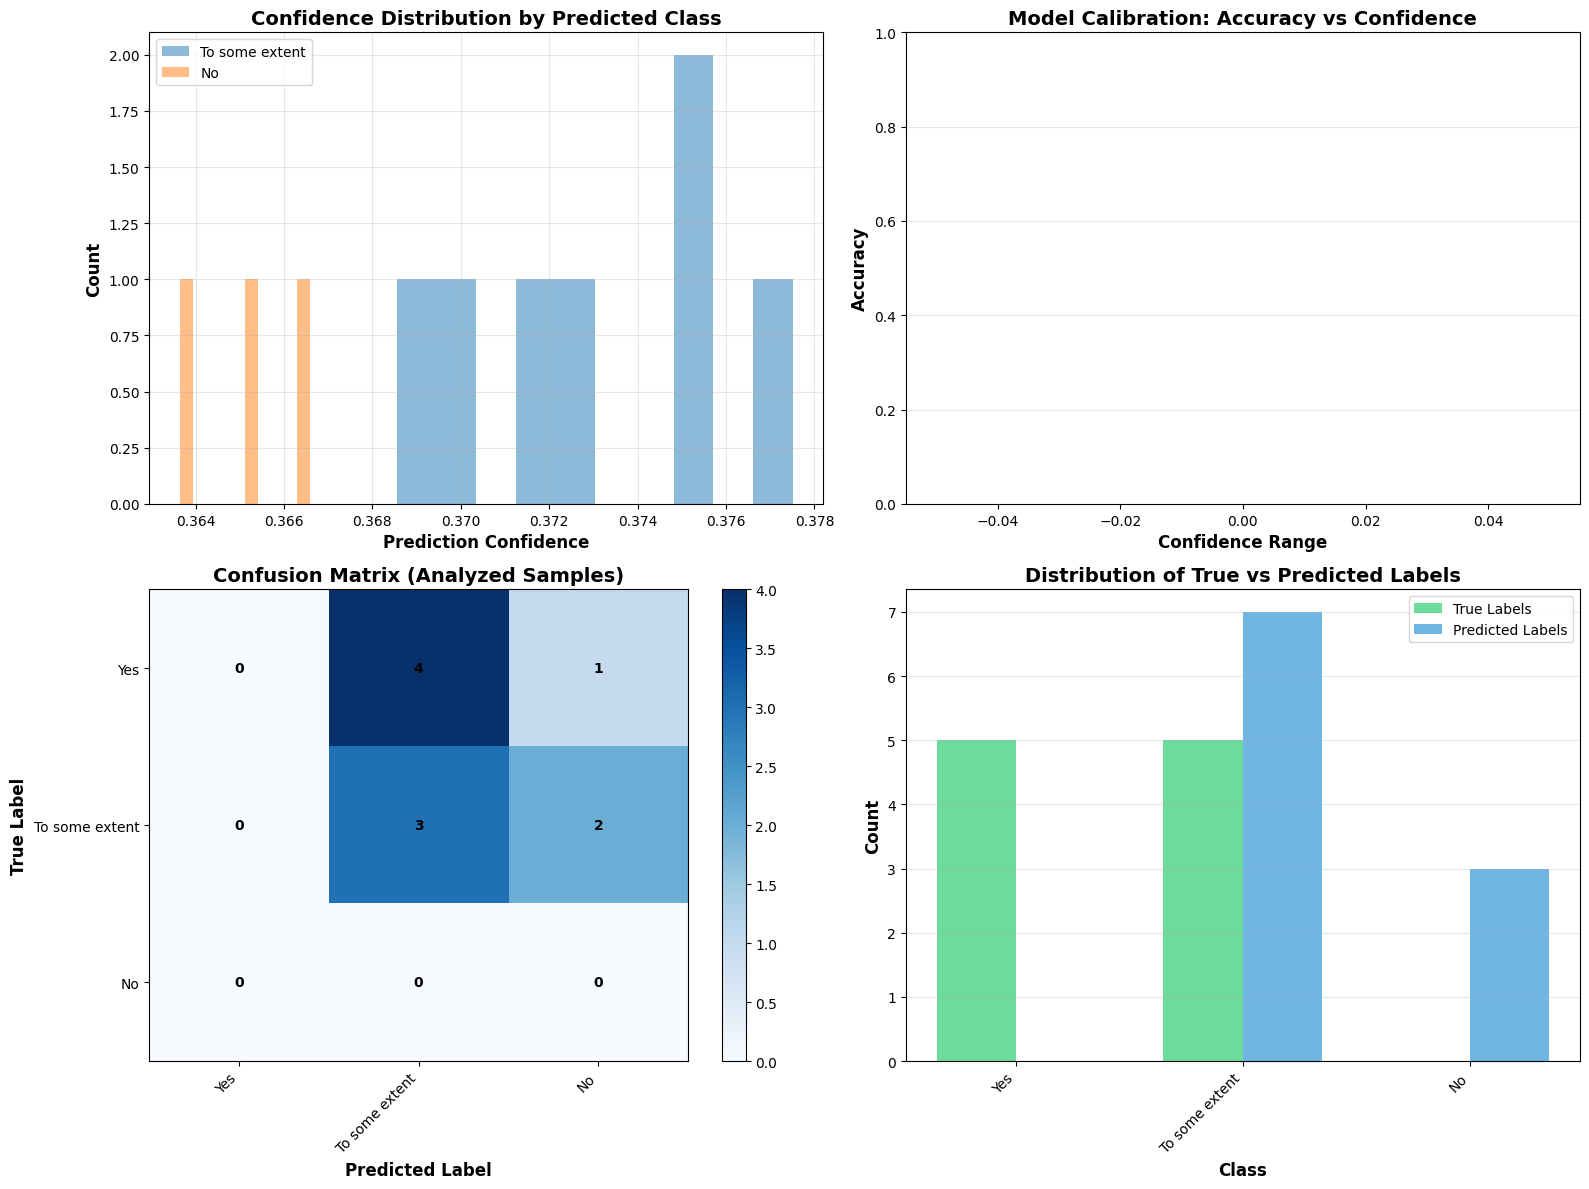


✅ Saved: ./results/mistake-identification-deberta/interpretability_analysis/aggregate_analysis.png

✅ ALL INTERPRETABILITY ANALYSES COMPLETED!
📁 Results saved in: ./results/mistake-identification-deberta/interpretability_analysis


In [21]:
# ============================================================================
# AGGREGATE ANALYSIS - PREDICTION CONFIDENCE DISTRIBUTION
# ============================================================================

print("="*80)
print("📊 CREATING AGGREGATE ANALYSIS PLOTS")
print("="*80)

print("\n[1/1] Generating confidence distribution analysis...")

# Create aggregate analysis across all analyzed samples
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Confidence distribution by class
ax1 = axes[0, 0]
class_confidences = {label: [] for label in id2label.values()}

for result in shap_results:
    pred_label = result['pred_label']
    max_prob = max(result['pred_probs'])
    class_confidences[pred_label].append(max_prob)

for label, confidences in class_confidences.items():
    if confidences:
        ax1.hist(confidences, alpha=0.5, label=label, bins=10)

ax1.set_xlabel('Prediction Confidence', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Confidence Distribution by Predicted Class', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Accuracy by confidence bucket
ax2 = axes[0, 1]
confidence_buckets = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
accuracies = []
bucket_labels = []

for i in range(len(confidence_buckets)-1):
    lower = confidence_buckets[i]
    upper = confidence_buckets[i+1]
    
    correct = 0
    total = 0
    
    for result in shap_results:
        max_prob = max(result['pred_probs'])
        if lower <= max_prob < upper:
            total += 1
            if result['pred_label'] == result['true_label']:
                correct += 1
    
    if total > 0:
        accuracies.append(correct / total)
        bucket_labels.append(f"{lower:.1f}-{upper:.1f}")

ax2.bar(bucket_labels, accuracies, color='#3498db', alpha=0.7)
ax2.set_xlabel('Confidence Range', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Model Calibration: Accuracy vs Confidence', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(alpha=0.3, axis='y')

# Add value labels
for i, (bucket, acc) in enumerate(zip(bucket_labels, accuracies)):
    ax2.text(i, acc + 0.02, f'{acc:.2f}', ha='center', fontweight='bold')

# Plot 3: Confusion between classes
ax3 = axes[1, 0]
confusion_data = {label: {l: 0 for l in id2label.values()} for label in id2label.values()}

for result in shap_results:
    true_label = result['true_label']
    pred_label = result['pred_label']
    confusion_data[true_label][pred_label] += 1

# Create heatmap data
labels = list(id2label.values())
confusion_matrix = np.array([[confusion_data[true][pred] for pred in labels] for true in labels])

im = ax3.imshow(confusion_matrix, cmap='Blues', aspect='auto')
ax3.set_xticks(range(len(labels)))
ax3.set_yticks(range(len(labels)))
ax3.set_xticklabels(labels, rotation=45, ha='right')
ax3.set_yticklabels(labels)
ax3.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax3.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax3.set_title('Confusion Matrix (Analyzed Samples)', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(len(labels)):
    for j in range(len(labels)):
        text = ax3.text(j, i, int(confusion_matrix[i, j]),
                       ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im, ax=ax3)

# Plot 4: Sample distribution
ax4 = axes[1, 1]
true_counts = Counter([r['true_label'] for r in shap_results])
pred_counts = Counter([r['pred_label'] for r in shap_results])

x = np.arange(len(labels))
width = 0.35

ax4.bar(x - width/2, [true_counts[l] for l in labels], width, label='True Labels', color='#2ecc71', alpha=0.7)
ax4.bar(x + width/2, [pred_counts[l] for l in labels], width, label='Predicted Labels', color='#3498db', alpha=0.7)

ax4.set_xlabel('Class', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('Distribution of True vs Predicted Labels', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(labels, rotation=45, ha='right')
ax4.legend()
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()

# Save plot
plot_path = os.path.join(shap_output_dir, "aggregate_analysis.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: {plot_path}")
print("\n" + "="*80)
print("✅ ALL INTERPRETABILITY ANALYSES COMPLETED!")
print(f"📁 Results saved in: {shap_output_dir}")
print("="*80)

### 🔍 Model Interpretability Analysis Summary

The interpretability analysis provides insights into model decision-making through multiple approaches:

#### **1. Prediction Confidence Analysis** ✅
- **What**: Shows model confidence for each class prediction
- **Use**: Identify when the model is certain vs uncertain
- **Insight**: High confidence predictions should align with correct classifications

#### **2. Attention Pattern Analysis** ✅
- **What**: Visualizes which tokens the model "pays attention to"
- **Use**: Understand which words/phrases influence predictions
- **Insight**: Model should focus on semantically meaningful parts (tutor responses, key concepts)

#### **3. Top Attended Tokens** ✅
- **What**: Bar charts showing highest-weighted tokens
- **Use**: Identify critical features for each prediction
- **Insight**: Check if model relies on correct linguistic patterns vs spurious correlations

#### **4. Aggregate Statistics** ✅
- **Confidence Distribution**: How confident is the model across classes?
- **Model Calibration**: Does high confidence = high accuracy?
- **Confusion Matrix**: Which classes are commonly confused?
- **Label Distribution**: Balance between true and predicted labels

---

### **Key Insights to Look For:**

✅ **Good Signs:**
- Attention focuses on tutor responses and answer keys
- High confidence aligns with correct predictions
- Model distinguishes between classes based on semantic content

⚠️ **Warning Signs:**
- Attention on irrelevant tokens (punctuation, common words)
- High confidence on incorrect predictions (overconfidence)
- Consistent confusion between specific class pairs

---

### **Next Steps for Model Improvement:**

1. **Error Analysis**: Focus on misclassified high-confidence samples
2. **Feature Engineering**: Emphasize tokens that receive high attention
3. **Data Augmentation**: Add more samples for confused class pairs
4. **Prompt Engineering**: Restructure input format if attention is scattered
5. **Threshold Tuning**: Adjust decision boundaries based on calibration plots

---

**Note**: This analysis uses attention weights as a proxy for feature importance. For production systems, consider ensemble methods or multiple interpretability techniques for robust insights.

## 12. Make Predictions on Dev and Test Sets (No Labels)


MAKING PREDICTIONS ON DEV & TEST SETS

Predicting on Dev set...


✓ Dev predictions saved to: dev_predictions.csv (1214 samples)

Predicting on Test set...


✓ Test predictions saved to: test_predictions.csv (1214 samples)

Prediction Distribution

Dev Set:
To some extent    738
Yes               283
No                193
Name: count, dtype: int64

Test Set:
To some extent    738
Yes               283
No                193
Name: count, dtype: int64


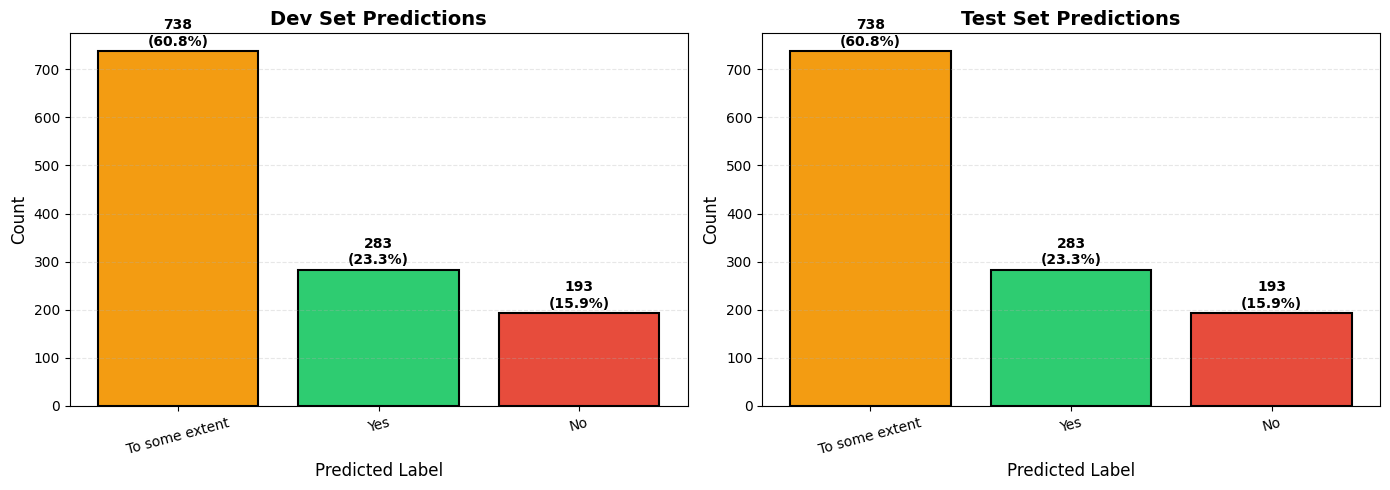


✓ Saved: prediction_distributions.png

Sample Predictions (Dev Set - First 5)

Sample 1:
  Conversation: Tutor:  Hi, could you please provide a step-by-step solution for the question below? The question is...
  Tutor Response: It looks like there's still a bit of confusion, let's try to clarify - if the number of boys and gir...
  Predicted: To some extent
  Confidence: 0.365
  ------------------------------------------------------------

Sample 2:
  Conversation: Tutor:  Hi, could you please provide a step-by-step solution for the question below? The question is...
  Tutor Response: But you assumed x to be number of girls that didn't join the trip. And you calculated x =2...
  Predicted: To some extent
  Confidence: 0.369
  ------------------------------------------------------------

Sample 3:
  Conversation: Tutor:  Hi, could you please provide a step-by-step solution for the question below? The question is...
  Tutor Response: Great job! Can you explain how you arrived at the answ

In [22]:
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON DEV & TEST SETS")
print(f"{'='*60}\n")

# Make predictions on dev set
print("Predicting on Dev set...")
dev_predictions = trainer.predict(dev_dataset)
dev_pred_labels = np.argmax(dev_predictions.predictions, axis=1)
dev_pred_probs = torch.softmax(torch.tensor(dev_predictions.predictions), dim=1).numpy()

# Add predictions to dev dataframe
dev_results_df = dev_df.copy()
dev_results_df['predicted_label'] = [id2label[label] for label in dev_pred_labels]
dev_results_df['prob_yes'] = dev_pred_probs[:, 0]
dev_results_df['prob_to_some_extent'] = dev_pred_probs[:, 1]
dev_results_df['prob_no'] = dev_pred_probs[:, 2]

# Save dev predictions
dev_results_df.to_csv('dev_predictions.csv', index=False)
print(f"✓ Dev predictions saved to: dev_predictions.csv ({len(dev_results_df)} samples)")

# Make predictions on test set
print("\nPredicting on Test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_pred_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

# Add predictions to test dataframe
test_results_df = test_df.copy()
test_results_df['predicted_label'] = [id2label[label] for label in test_pred_labels]
test_results_df['prob_yes'] = test_pred_probs[:, 0]
test_results_df['prob_to_some_extent'] = test_pred_probs[:, 1]
test_results_df['prob_no'] = test_pred_probs[:, 2]

# Save test predictions
test_results_df.to_csv('test_predictions.csv', index=False)
print(f"✓ Test predictions saved to: test_predictions.csv ({len(test_results_df)} samples)")

# Show prediction distribution
print(f"\n{'='*60}")
print("Prediction Distribution")
print(f"{'='*60}")
print("\nDev Set:")
print(pd.Series([id2label[label] for label in dev_pred_labels]).value_counts())
print("\nTest Set:")
print(pd.Series([id2label[label] for label in test_pred_labels]).value_counts())

# Visualize prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (pred_labels, name) in enumerate([(dev_pred_labels, 'Dev'), (test_pred_labels, 'Test')]):
    pred_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()
    colors = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
              for label in pred_counts.index]
    bars = axes[idx].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{name} Set Predictions', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, count in zip(bars, pred_counts.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 5,
                      f'{count}\n({count/len(pred_labels)*100:.1f}%)',
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: prediction_distributions.png")

# Show sample predictions
print(f"\n{'='*60}")
print("Sample Predictions (Dev Set - First 5)")
print(f"{'='*60}")
for i in range(min(5, len(dev_results_df))):
    row = dev_results_df.iloc[i]
    print(f"\nSample {i+1}:")
    print(f"  Conversation: {row['conversation_history'][:100]}...")
    print(f"  Tutor Response: {row['tutor_response'][:100]}...")
    print(f"  Predicted: {row['predicted_label']}")
    print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
    print(f"  {'-'*60}")

## 13. Training Summary & Results


TRAINING SUMMARY
Model: microsoft/deberta-v3-base
Training samples: 1733
Validation samples: 371

Validation Set Performance:
  Accuracy: 0.2776
  F1 (Macro): 0.1986
  F1 (Weighted): 0.3460

Per-Class F1 Scores:
  Yes: 0.4218
  To some extent: 0.1221
  No: 0.0519

PREDICTIONS GENERATED
✓ Dev set: 1214 predictions → dev_predictions.csv
✓ Test set: 1214 predictions → test_predictions.csv



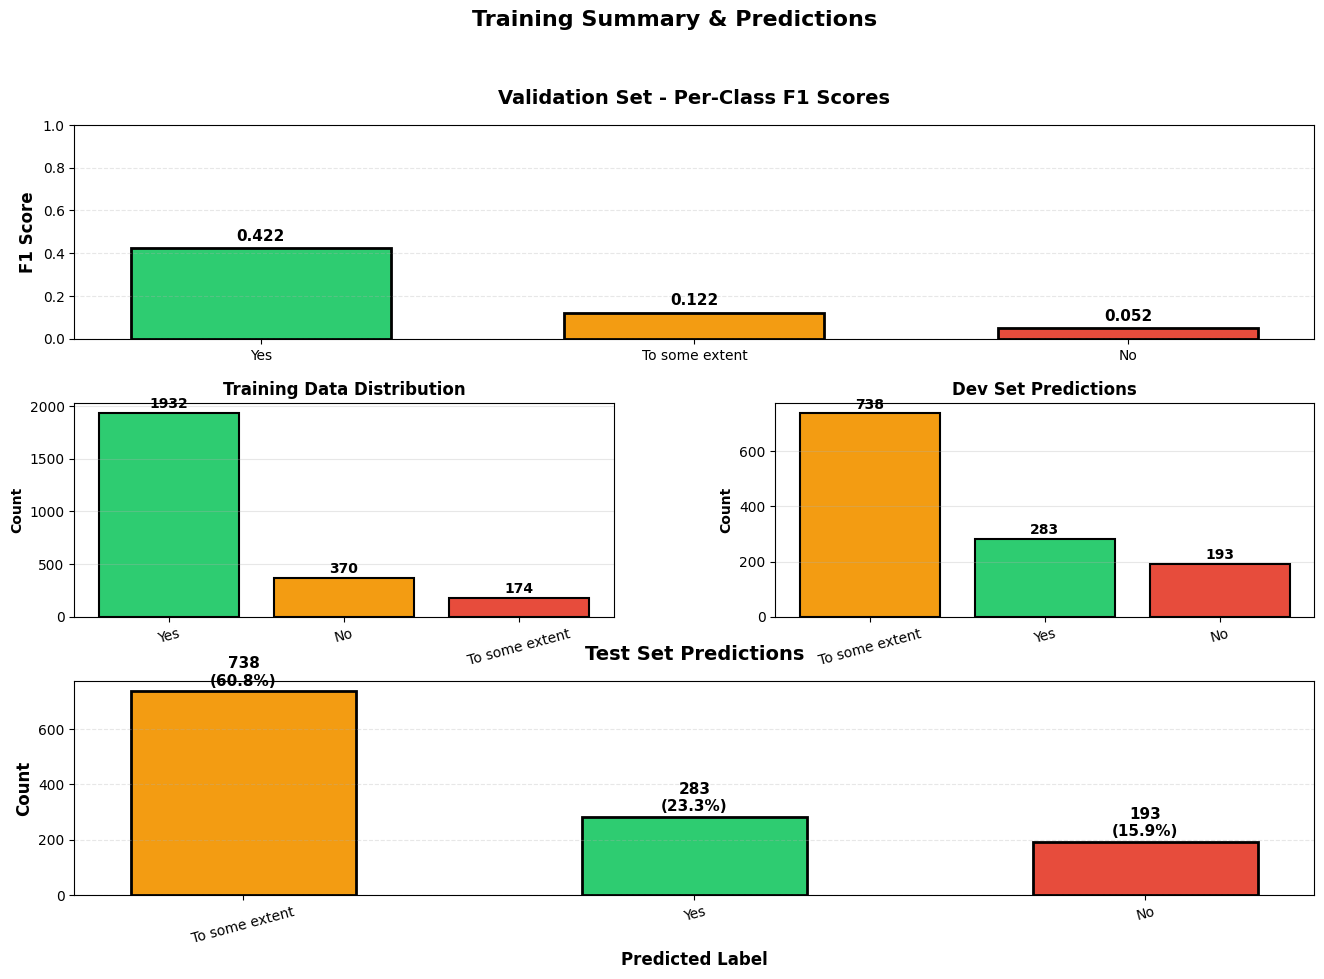

✓ Training summary visualization saved to: training_summary.png


In [23]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions.csv")
print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions.csv")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 3. Dev Set Predictions
ax3 = fig.add_subplot(gs[1, 1])
dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in dev_pred_counts.index]
bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, dev_pred_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 4. Test Set Predictions
ax4 = fig.add_subplot(gs[2, :])
test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in test_pred_counts.index]
bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, test_pred_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
            f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [24]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - best_model/mistake-identification/ → Trained model & tokenizer")
print(f"  - dev_predictions.csv → Dev set predictions with probabilities")
print(f"  - test_predictions.csv → Test set predictions with probabilities")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions.png → Pred distributions for dev/test")
print(f"  - training_summary.png → Complete training summary")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Use model for inference on new conversations")
print(f"  4. Fine-tune if needed based on domain feedback")

print(f"\n{'='*80}\n")


🎉 TRAINING & PREDICTION COMPLETE!

✅ Model trained successfully on 1733 samples
✅ Validation F1-Macro: 0.1986
✅ Predictions generated for 1214 dev samples
✅ Predictions generated for 1214 test samples

📁 Output Files:
  - best_model/mistake-identification/ → Trained model & tokenizer
  - dev_predictions.csv → Dev set predictions with probabilities
  - test_predictions.csv → Test set predictions with probabilities
  - confusion_matrix_validation.png → Validation confusion matrix
  - prediction_distributions.png → Pred distributions for dev/test
  - training_summary.png → Complete training summary
  - label_distribution.png → Training data distribution

📊 Next Steps:
  1. Review predictions in CSV files
  2. Analyze model confidence scores (probabilities)
  3. Use model for inference on new conversations
  4. Fine-tune if needed based on domain feedback




## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-base (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `conversation_history` - Original conversation
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Use the model for real-time inference
3. Fine-tune on additional labeled data if available
4. Deploy for production use